In [1]:
import numpy as np 
import os 
import xarray as xr
import pandas as pd

from collections import OrderedDict
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import matplotlib as mpl
from matplotlib import colors
from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.pyplot import cm
import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
import matplotlib.patches as mpatches
from mpl_axes_aligner import align
import cmasher as cmr

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats

import sys 
import re 
import yaml
import inspect 
from collections import defaultdict

In [2]:
dirpath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/'
days_of_week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_type_list = ['Weekday', 'Weekend']
weekday_type_list_sunday = ['Weekday','Sunday']
hour_range = np.arange(0,24,1)

ozone_filepath = dirpath + '/Plotting/USOS_Campaign_analysis/all_ozone_during_usos_with_exceedances.csv'


In [3]:
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['axes.titlesize'] = 28
mpl.rcParams['axes.xmargin'] = 0

# Set the font family to 'serif'
mpl.rcParams['font.family'] = 'serif'
# Specify 'cmr10' as the preferred serif font (Computer Modern Roman)
mpl.rcParams['font.serif'] = 'cmr10' 
# Optionally, configure mathtext to use Computer Modern fonts as well
mpl.rcParams['mathtext.fontset'] = 'cm'
# Ensure minus signs are rendered correctly with CM fonts
mpl.rcParams['axes.unicode_minus'] = False

In [4]:
all_days_filepath = dirpath + 'CampaignData_and_Merges/R0/CSL_MobileLab_Parked/merged/rev_30min/all_CSL_MobileLab_Parked_rev30minv4.nc'
all_days_filepath_load = xr.open_dataset(all_days_filepath)
df_alldays = all_days_filepath_load.to_dataframe()
df_alldays.reset_index(inplace=True)
df_alldays.set_index('time_local', inplace=True, drop=False)

df_alldays_resample = df_alldays.resample('1h').mean()

#adds padding of NaNs for first day and last day of campaign, since they need to have the same length of time as the other days in order to plot
new_start_time = pd.Timestamp('2024-07-15 00:00:00')
new_end_time = pd.Timestamp('2024-08-18 23:00:00')
# Create a new datetime index from new_start to the end of existing index with same frequency
new_index = pd.date_range(start=new_start_time, end=new_end_time, freq='1h')
# Reindex the dataframe to include new rows
df_alldays = df_alldays_resample.reindex(new_index)
print(df_alldays['NO_LIF'].values)

[ 1.01644940e+00  2.01828289e+00  5.77177482e-02  3.65703887e-02
  3.73620963e-02  5.16136094e-02  1.78768659e-01  1.51784251e+00
  2.53351896e+00  1.60595641e+00  1.10573467e+00  1.31810358e+00
  7.01526093e-01  5.28240653e-01  3.53743837e-01  4.37122271e-01
  4.33877296e-01  3.02330185e-01  2.68159904e-01  1.91205112e-01
  9.66083492e-02  7.21755853e-02  1.11920323e-01  4.61523463e-01
  5.36216059e-01  9.77642677e-02  6.18329683e-02  6.46642749e-02
  4.31040993e-02  9.12999473e-02  4.16969568e-01  1.47443191e+00
  3.90866669e+00  4.26698782e+00  1.27272786e+00  8.18047518e-01
  8.49836178e-01  5.80520511e-01  3.47245344e-01  4.22365967e-01
  5.09576701e-01  3.38745567e-01  6.76449127e-01  1.23739582e+00
  2.32201524e+00  1.07986474e-01  1.38303535e-01  2.20726709e-01
  1.14243271e-01  4.00899027e-02  2.10493283e-02  1.62676014e-02
  3.24728245e-02  6.29066190e-02  1.63545535e-01  2.96314488e-01
  6.94598863e-01  5.38217586e-01  4.09208624e-01  4.37850656e-01
  5.13397634e-01  5.09325

In [5]:
df_alldays['NO_LIF'] = df_alldays['NO_LIF'].mask(df_alldays['NO_LIF'] < 0)
print(df_alldays['NO_LIF'].values)

pressure_mb = df_alldays['Press_mb_POPS']
temp_celsius = df_alldays['Temp_C_POPS']
photolysis_no2_meas = df_alldays['jNO2_meas']
no_mobilelab = df_alldays['NO_LIF']
print(no_mobilelab.values)
no2_mobilelab = df_alldays['NO2_LIF']
o3_mobilelab = df_alldays['O3_ppbv']

df_alldays['NOx_ppbv'] = df_alldays['NO_LIF'] + df_alldays['NO2_LIF']


[ 1.0164494   2.01828289  0.05771775  0.03657039  0.0373621   0.05161361
  0.17876866  1.51784251  2.53351896  1.60595641  1.10573467  1.31810358
  0.70152609  0.52824065  0.35374384  0.43712227  0.4338773   0.30233019
  0.2681599   0.19120511  0.09660835  0.07217559  0.11192032  0.46152346
  0.53621606  0.09776427  0.06183297  0.06466427  0.0431041   0.09129995
  0.41696957  1.47443191  3.90866669  4.26698782  1.27272786  0.81804752
  0.84983618  0.58052051  0.34724534  0.42236597  0.5095767   0.33874557
  0.67644913  1.23739582  2.32201524  0.10798647  0.13830353  0.22072671
  0.11424327  0.0400899   0.02104933  0.0162676   0.03247282  0.06290662
  0.16354553  0.29631449  0.69459886  0.53821759  0.40920862  0.43785066
  0.51339763  0.50932522  0.43599364  0.51204383  0.51438266  0.6284265
  0.18796371  0.2103138   0.0961042   0.04206005  0.11421301  0.12748922
  0.05943497  0.0243354   0.06505805  0.01825246  0.04527447  0.08622814
  1.75345103  1.60016721  3.97131424  3.48829317  2.

In [6]:
#ppbv to molecs/cm^3 conversion
pressure_pa = pressure_mb * 10**2
temp_kelvin = temp_celsius + 273.15
gas_constant = 8.31446261815324 * 10**6 #cm^3 * Pa * K^−1 * mol^−1

#70 ppbv= 70x10^-9 mol/mol 
volume_mixing_ratio_no = no_mobilelab/10**9
volume_mixing_ratio_no2 = no2_mobilelab/10**9
volume_mixing_ratio_o3 = o3_mobilelab/10**9
num_density_air = ((6.022*10**23) * pressure_pa) / (gas_constant * temp_kelvin)
num_density_no =  num_density_air * volume_mixing_ratio_no
num_density_no2 = num_density_air * volume_mixing_ratio_no2
num_density_o3 = num_density_air * volume_mixing_ratio_o3

df_alldays['num_density_no'] = num_density_no
df_alldays['num_density_no2'] = num_density_no2
df_alldays['num_density_nox'] = num_density_no + num_density_no2
df_alldays['num_density_o3'] = num_density_o3

#based off JPL kinetics publication
k_rate_o3_no = (3.0*10**-12) * np.exp(-1500*(1/temp_kelvin))

In [7]:
prod_o3_num = photolysis_no2_meas * num_density_no2
loss_o3_den = k_rate_o3_no * num_density_no * num_density_o3
leighton_ratio = prod_o3_num / loss_o3_den
no_no2_ratio = (df_alldays['num_density_no'])/(df_alldays['num_density_no2'])

df_alldays['prod_o3_num'] = prod_o3_num
df_alldays['loss_o3_den'] = loss_o3_den
df_alldays['leighton ratio'] = leighton_ratio
df_alldays['no_no2_ratio'] = no_no2_ratio

/tmp/ipykernel_3838838/3501466948.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(figsize = (30,10))


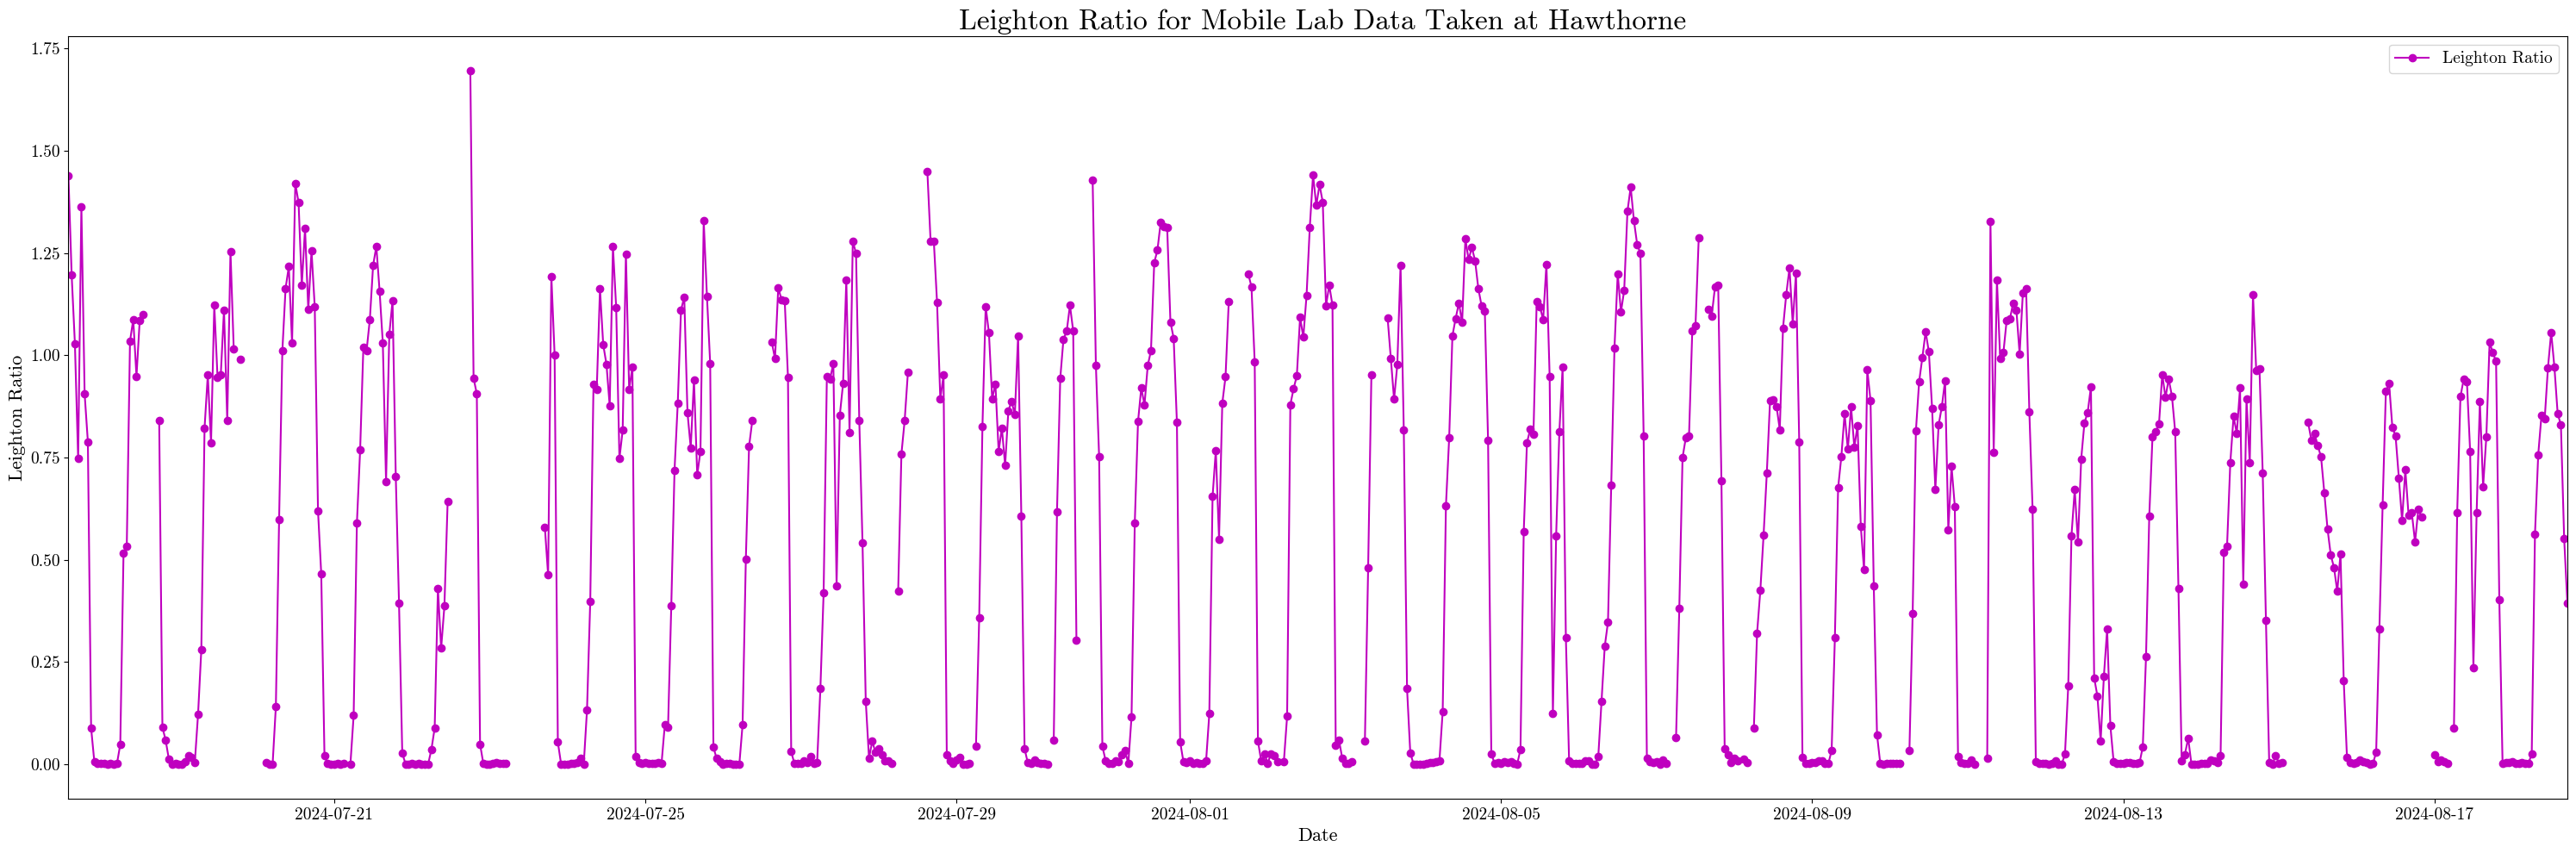

In [8]:
fig, ax = plt.subplots(figsize = (30,10))
plt.plot(df_alldays.index, df_alldays['leighton ratio'], color = 'm', marker = 'o', label = 'Leighton Ratio')
plt.ylabel( 'Leighton Ratio', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.legend(fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(' Leighton Ratio for Mobile Lab Data Taken at Hawthorne', fontsize = 24)
plt.tight_layout()
#plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/hawthorne_udaq_usos_'+str(voc_species_names[species])+'_comparison.png', dpi =300)
plt.show()
# df_reshaped_hawthorne_species.columns.name = None

/tmp/ipykernel_3838838/2698121336.py:6: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax1 = plt.subplots(figsize = (30,10))
/tmp/ipykernel_3838838/2698121336.py:14: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax2=ax1.twinx()


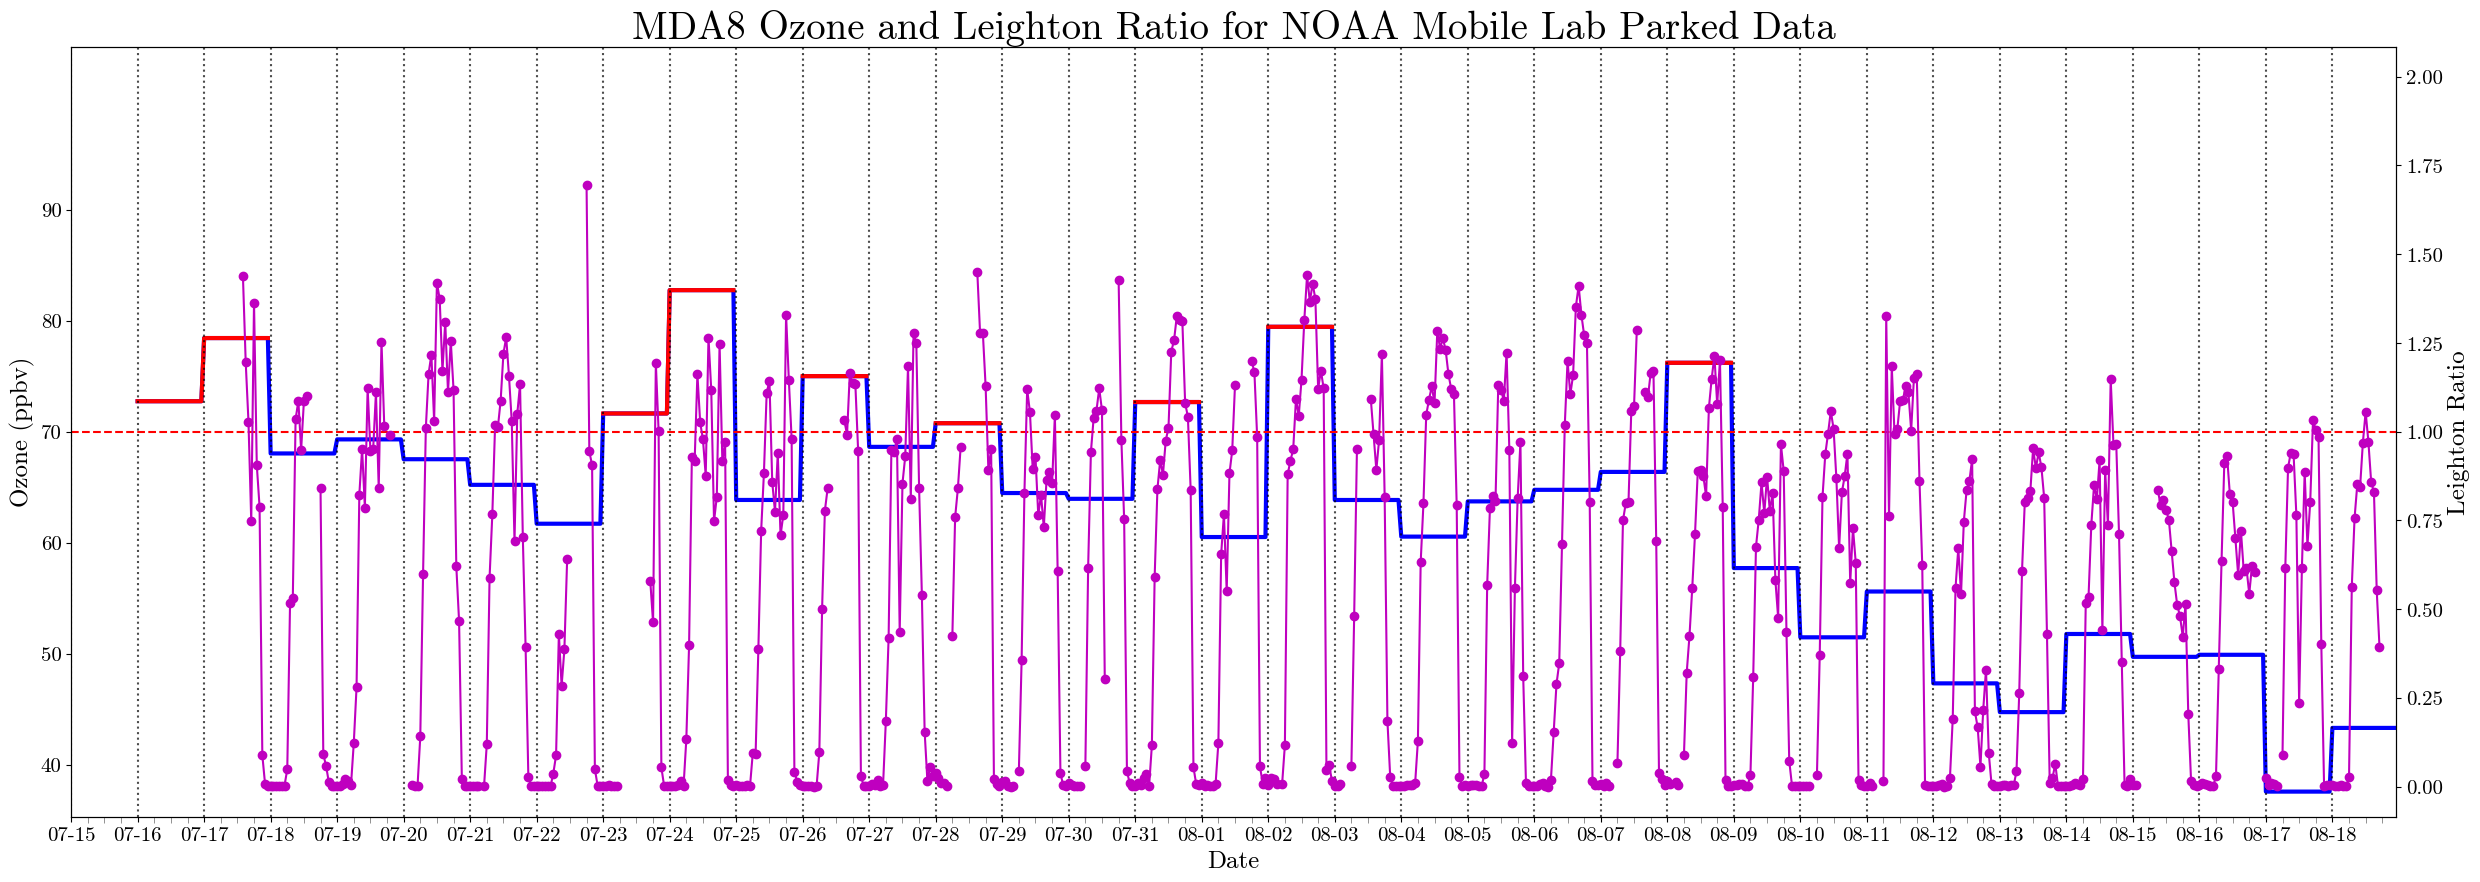

In [9]:
ozone_saved_filepath = dirpath + 'Plotting/USOS_Campaign_analysis/all_ozone_during_usos_with_exceedances.csv'
df_all_o3_load = pd.read_csv(ozone_saved_filepath, index_col='dt', parse_dates=True)

threshold = 70

fig, ax1 = plt.subplots(figsize = (30,10))
mda8_ozone_name = 'MDA8_O3_' + df_all_o3_load.columns[0]
exceedance_name = 'Exceedance_day_' + df_all_o3_load.columns[0]
mda8_exceedance = np.where(df_all_o3_load[mda8_ozone_name].values > threshold, df_all_o3_load[mda8_ozone_name].values , np.nan)

ax1.plot(df_all_o3_load.index, df_all_o3_load[mda8_ozone_name], color='b', linewidth = 3)
ax1.plot(df_all_o3_load.index, mda8_exceedance, color='r', linewidth = 3)

ax2=ax1.twinx()
ax2.plot(df_alldays.index, df_alldays['leighton ratio'], color = 'm', marker = 'o', label = 'Leighton Ratio')

ax1.margins(x=0)
ax1.set_ylabel('Ozone (ppbv)')
ax1.set_xlabel('Date')
ax1.hlines(y=70, xmin = df_all_o3_load.index[0], xmax = df_all_o3_load.index[len(df_all_o3_load.index)-1], linestyle = 'dashed', color = 'r')
ax1.set_title('MDA8 Ozone and Leighton Ratio for NOAA Mobile Lab Parked Data')

ax2.set_ylabel('Leighton Ratio')
align.yaxes(ax1, 70, ax2, 1.00, 0.5)

ax1.xaxis.set_major_locator(mdates.DayLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# Minor ticks: every 6 hours
ax1.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))

# Rotate and format tick labels
ax1.tick_params(axis='x', which='major')
ax1.tick_params(axis='x', which='minor', length=4, color='gray')

ax1.set_yticks(np.arange(40,100,10))

midnight_vals = []
for midnight_idx in range(0,len(df_all_o3_load.index),24):
    midnight_vals.append(df_all_o3_load.index[midnight_idx])
for day_pos in midnight_vals:
    ax1.axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)

In [10]:
ozone_filepath = dirpath + '/Plotting/USOS_Campaign_analysis/all_ozone_during_usos_with_exceedances.csv'
df_ozone = pd.read_csv(ozone_filepath, index_col='dt', parse_dates=True)
print(df_ozone.columns.values)
df_alldays['ozone exceedances mobile lab'] = df_ozone['Exceedance_day_Mobile Lab O3']

['Mobile Lab O3' 'UDAQ O3' 'merged_ozone' '8hr_rolling_avg_Mobile Lab O3'
 'MDA8_O3_Mobile Lab O3' 'Exceedance_day_Mobile Lab O3'
 '8hr_rolling_avg_UDAQ O3' 'MDA8_O3_UDAQ O3' 'Exceedance_day_UDAQ O3'
 '8hr_rolling_avg_merged_ozone' 'MDA8_O3_merged_ozone'
 'Exceedance_day_merged_ozone']


In [11]:
month_index = df_alldays.index.month
date_index = df_alldays.index.date
day_names_index = df_alldays.index.day_name()
hr_of_day_index = df_alldays.index.time
weekday_index = df_alldays.index.weekday
df_alldays['Weekday'] = np.where(weekday_index < 5, 'Weekday', 'Weekend')
df_alldays['Sunday'] = np.where(weekday_index == 6, 'Sunday', 'Not-Sunday')

# overall_ozone_avg_usos = df_ozone['USOS O3'].groupby([hr_of_day_index_ozone]).mean()
# overall_ozone_std_usos = np.std(overall_ozone_avg_usos)

overall_ozone_avg_mobile_lab = df_alldays['O3_ppbv'].groupby([hr_of_day_index]).mean()
overall_ozone_std_mobile_lab = np.std(overall_ozone_avg_mobile_lab)
day_of_week_ozone_ppbv_mean_mobile_lab = df_alldays.groupby([day_names_index, hr_of_day_index])['O3_ppbv'].mean()
weekday_ozone_ppbv_mean_mobile_lab = df_alldays.groupby(['Weekday', hr_of_day_index])['O3_ppbv'].mean()

day_of_week_num_density_o3_mean = df_alldays.groupby([day_names_index, hr_of_day_index])['num_density_o3'].mean()
weekday_num_density_o3_mean = df_alldays.groupby(['Weekday', hr_of_day_index])['num_density_o3'].mean()

overall_no_ppbv_avg_mobile_lab = df_alldays['NO_LIF'].groupby([hr_of_day_index]).mean()
overall_no_ppbv_std_mobile_lab = np.std(overall_no_ppbv_avg_mobile_lab)
day_of_week_no_ppbv_mean = df_alldays.groupby([day_names_index, hr_of_day_index])['NO_LIF'].mean()
weekday_no_ppbv_mean = df_alldays.groupby(['Weekday', hr_of_day_index])['NO_LIF'].mean()

overall_no2_ppbv_avg_mobile_lab = df_alldays['NO2_LIF'].groupby([hr_of_day_index]).mean()
overall_no2_ppbv_std_mobile_lab = np.std(overall_no2_ppbv_avg_mobile_lab)
day_of_week_no2_ppbv_mean = df_alldays.groupby([day_names_index, hr_of_day_index])['NO2_LIF'].mean()
weekday_no2_ppbv_mean = df_alldays.groupby(['Weekday', hr_of_day_index])['NO2_LIF'].mean()

overall_nox_ppbv_avg_mobile_lab = df_alldays['NOx_ppbv'].groupby([hr_of_day_index]).mean()
overall_nox_ppbv_std_mobile_lab = np.std(overall_nox_ppbv_avg_mobile_lab)
day_of_week_nox_ppbv_mean = df_alldays.groupby([day_names_index, hr_of_day_index])['NOx_ppbv'].mean()
weekday_nox_ppbv_mean = df_alldays.groupby(['Weekday', hr_of_day_index])['NOx_ppbv'].mean()

overall_leighton_ratio_avg_mobile_lab = df_alldays['leighton ratio'].groupby([hr_of_day_index]).mean()
overall_leighton_ratio_std_mobile_lab = np.std(overall_leighton_ratio_avg_mobile_lab)
day_of_week_leighton_ratio_mean = df_alldays.groupby([day_names_index, hr_of_day_index])['leighton ratio'].mean()
weekday_leighton_ratio_mean = df_alldays.groupby(['Weekday', hr_of_day_index])['leighton ratio'].mean()

day_of_week_prod_o3_num_mean = df_alldays.groupby([day_names_index, hr_of_day_index])['prod_o3_num'].mean()
weekday_prod_o3_num_mean = df_alldays.groupby(['Weekday', hr_of_day_index])['prod_o3_num'].mean()

day_of_week_loss_o3_den_mean = df_alldays.groupby([day_names_index, hr_of_day_index])['loss_o3_den'].mean()
weekday_loss_o3_den_mean = df_alldays.groupby(['Weekday', hr_of_day_index])['loss_o3_den'].mean()

day_of_week_no_no2_ratio = df_alldays.groupby([day_names_index, hr_of_day_index])['no_no2_ratio'].mean()
weekday_no_no2_ratio = df_alldays.groupby(['Weekday', hr_of_day_index])['no_no2_ratio'].mean()

percent_no = (df_alldays['num_density_no']/df_alldays['num_density_nox'])*100
df_alldays['percent_no'] = percent_no
day_of_week_percent_no_mean = df_alldays.groupby([day_names_index, hr_of_day_index])['percent_no'].mean()
weekday_loss_percent_no_mean = df_alldays.groupby(['Weekday', hr_of_day_index])['percent_no'].mean()

percent_no_ppbv = (df_alldays['NO_LIF']/df_alldays['NOx_ppbv'])*100
df_alldays['percent_no_ppbv'] = percent_no_ppbv
day_of_week_percent_no_ppbv_mean = df_alldays.groupby([day_names_index, hr_of_day_index])['percent_no_ppbv'].mean()
weekday_loss_percent_no_mean = df_alldays.groupby(['Weekday', hr_of_day_index])['percent_no_ppbv'].mean()

day_of_week_no2_photolysis = df_alldays.groupby([day_names_index, hr_of_day_index])['jNO2_meas'].mean()
weekday_no2_photolysis= df_alldays.groupby(['Weekday', hr_of_day_index])['jNO2_meas'].mean()

/tmp/ipykernel_3838838/3825001451.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, (ax1, ax2) = plt.subplots(1,2, figsize = (20,10), layout='tight')


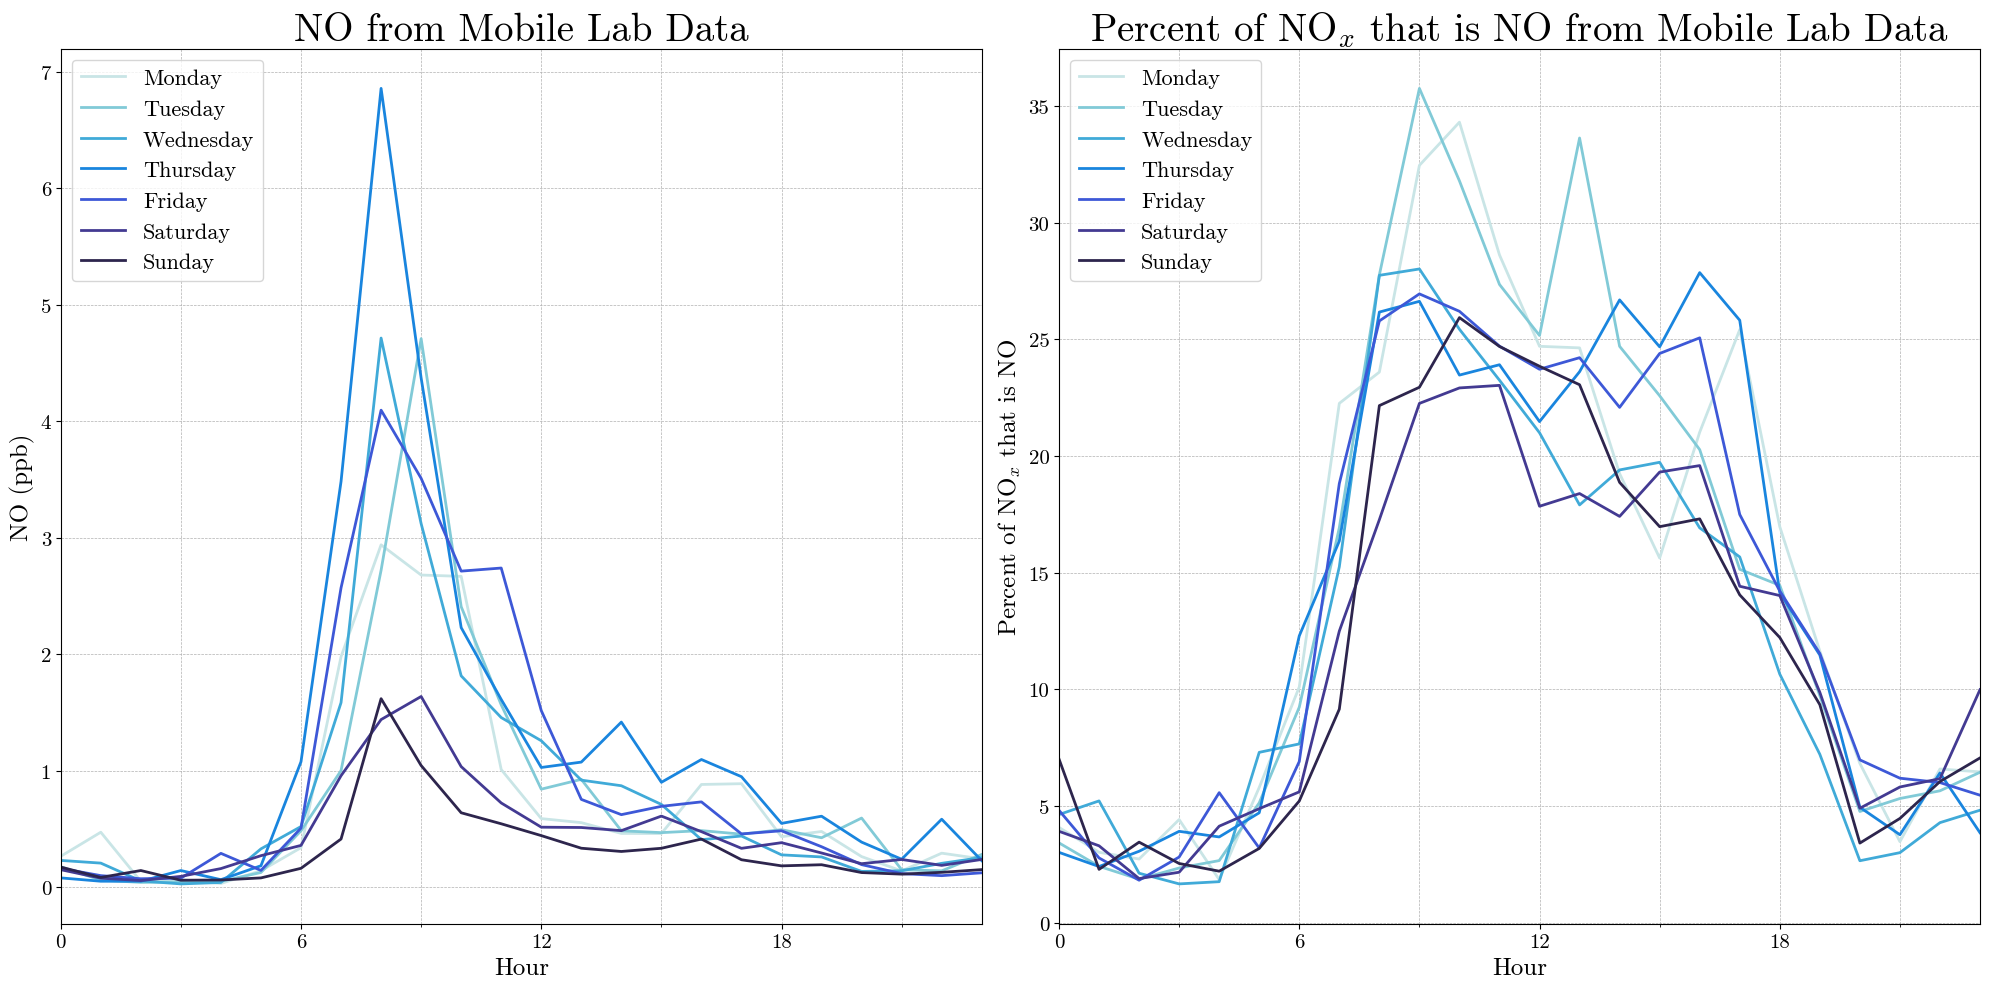

In [12]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (20,10), layout='tight')
plt.rcParams['figure.figsize'] = [1.618 * i for i in plt.rcParams['figure.figsize']]
plt.rcParams['figure.subplot.wspace'] = 0.3

colors = cmr.take_cmap_colors('cmr.freeze_r', 7, cmap_range=(0.1, 0.8), return_fmt='hex')

for day_val in range(0,7):
    ax1.plot(hour_range, day_of_week_no_ppbv_mean[days_of_week[day_val]], 
               color=colors[day_val], label = days_of_week[day_val], linewidth = 2)
    ax1.set_xlabel('Hour')
    ax1.set_ylabel('NO (ppb)')
    ax1.set_title('NO from Mobile Lab Data')

    ax2.plot(hour_range, day_of_week_percent_no_mean[days_of_week[day_val]], 
               color=colors[day_val], label = days_of_week[day_val], linewidth = 2)
    ax2.set_xlabel('Hour')
    ax2.set_ylabel('Percent of NO$_x$ that is NO')
    ax2.set_title('Percent of NO$_x$ that is NO from Mobile Lab Data')
#ax1.plot(hour_range, overall_nox_avg, color = 'k', label = 'Campaign Average')
#ax1.fill_between(hour_range, overall_nox_avg - overall_nox_std, overall_nox_avg + overall_nox_std, color='k',alpha = 0.1)
ax1.xaxis.set_minor_locator(MultipleLocator(3))
ax1.xaxis.set_major_locator(MultipleLocator(6))
ax1.grid(which='both', linestyle='--', linewidth=0.5)
ax1.legend(loc='upper left')

#ax2.plot(hour_range, o3_avg_from, color = 'k', label = 'Campaign Average')
#ax2.fill_between(hour_range, o3_avg_from - o3_std_from, o3_avg_from + o3_std_from, color='k',alpha = 0.1)
ax2.xaxis.set_minor_locator(MultipleLocator(3))
ax2.xaxis.set_major_locator(MultipleLocator(6))
ax2.grid(which='both', linestyle='--', linewidth=0.5)
ax2.legend(loc='upper left')

plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/no_percent_nox_as_no.png', dpi =150)
plt.show()

In [13]:
#Difference in avg NO on weekdays vs weekend days
# print(weekday_no_ppbv_mean['Weekday'])
# print(day_of_week_no_ppbv_mean['Saturday'])
# print(day_of_week_no_ppbv_mean['Sunday'])
print(weekday_no_ppbv_mean['Weekday'])
weekday_morning_avg_no = weekday_no_ppbv_mean['Weekday'].iloc[7:12].mean()
satuday_morning_avg_no = day_of_week_no_ppbv_mean['Saturday'].iloc[7:12].mean()
sunday_morning_avg_no = day_of_week_no_ppbv_mean['Sunday'].iloc[7:12].mean()

percent_decrease_saturday = ((weekday_morning_avg_no-satuday_morning_avg_no)/weekday_morning_avg_no)*100
percent_decrease_sunday = ((weekday_morning_avg_no-sunday_morning_avg_no)/weekday_morning_avg_no)*100
print(percent_decrease_saturday)
print(percent_decrease_sunday)

00:00:00    0.182680
01:00:00    0.178181
02:00:00    0.053990
03:00:00    0.071966
04:00:00    0.095799
05:00:00    0.185219
06:00:00    0.590159
07:00:00    2.113459
08:00:00    4.219862
09:00:00    3.635451
10:00:00    2.349858
11:00:00    1.635437
12:00:00    1.055317
13:00:00    0.849031
14:00:00    0.751679
15:00:00    0.645587
16:00:00    0.698972
17:00:00    0.605171
18:00:00    0.446046
19:00:00    0.424084
20:00:00    0.314704
21:00:00    0.159372
22:00:00    0.271078
23:00:00    0.230452
Name: NO_LIF, dtype: float64
58.48700252364611
69.46458725861609


/tmp/ipykernel_3838838/353978190.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, (ax1, ax2) = plt.subplots(1,2, figsize = (20,10), layout='tight')


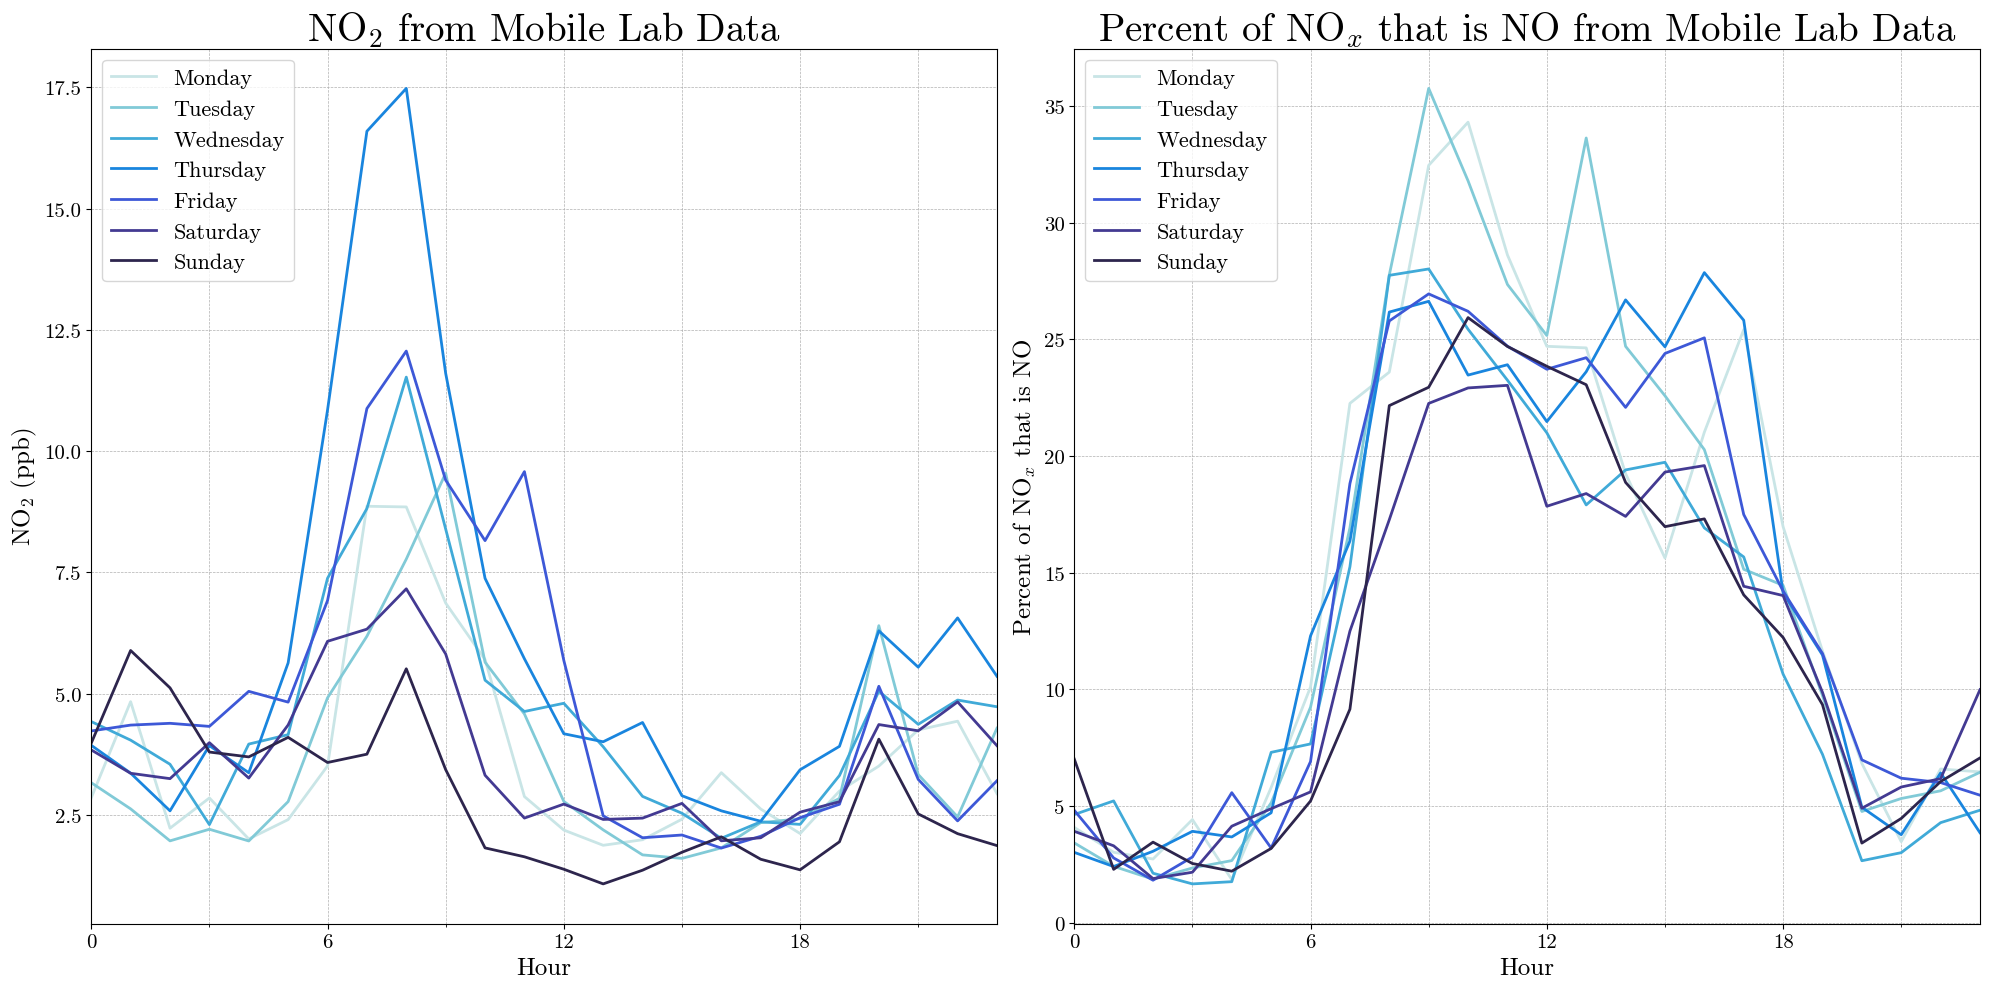

In [14]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (20,10), layout='tight')
plt.rcParams['figure.figsize'] = [1.618 * i for i in plt.rcParams['figure.figsize']]
plt.rcParams['figure.subplot.wspace'] = 0.3

colors = cmr.take_cmap_colors('cmr.freeze_r', 7, cmap_range=(0.1, 0.8), return_fmt='hex')

for day_val in range(0,7):
    ax1.plot(hour_range, day_of_week_no2_ppbv_mean[days_of_week[day_val]], 
               color=colors[day_val], label = days_of_week[day_val], linewidth = 2)
    ax1.set_xlabel('Hour')
    ax1.set_ylabel('NO$_2$ (ppb)')
    ax1.set_title('NO$_2$ from Mobile Lab Data')

    ax2.plot(hour_range, day_of_week_percent_no_mean[days_of_week[day_val]], 
               color=colors[day_val], label = days_of_week[day_val], linewidth = 2)
    ax2.set_xlabel('Hour')
    ax2.set_ylabel('Percent of NO$_x$ that is NO')
    ax2.set_title('Percent of NO$_x$ that is NO from Mobile Lab Data')
#ax1.plot(hour_range, overall_nox_avg, color = 'k', label = 'Campaign Average')
#ax1.fill_between(hour_range, overall_nox_avg - overall_nox_std, overall_nox_avg + overall_nox_std, color='k',alpha = 0.1)
ax1.xaxis.set_minor_locator(MultipleLocator(3))
ax1.xaxis.set_major_locator(MultipleLocator(6))
ax1.grid(which='both', linestyle='--', linewidth=0.5)
ax1.legend(loc='upper left')

#ax2.plot(hour_range, o3_avg_from, color = 'k', label = 'Campaign Average')
#ax2.fill_between(hour_range, o3_avg_from - o3_std_from, o3_avg_from + o3_std_from, color='k',alpha = 0.1)
ax2.xaxis.set_minor_locator(MultipleLocator(3))
ax2.xaxis.set_major_locator(MultipleLocator(6))
ax2.grid(which='both', linestyle='--', linewidth=0.5)
ax2.legend(loc='upper left')

#plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/no_percent_nox_as_no.png', dpi =150)
plt.show()

/tmp/ipykernel_3838838/2011447653.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(1,2, figsize = (20,10))


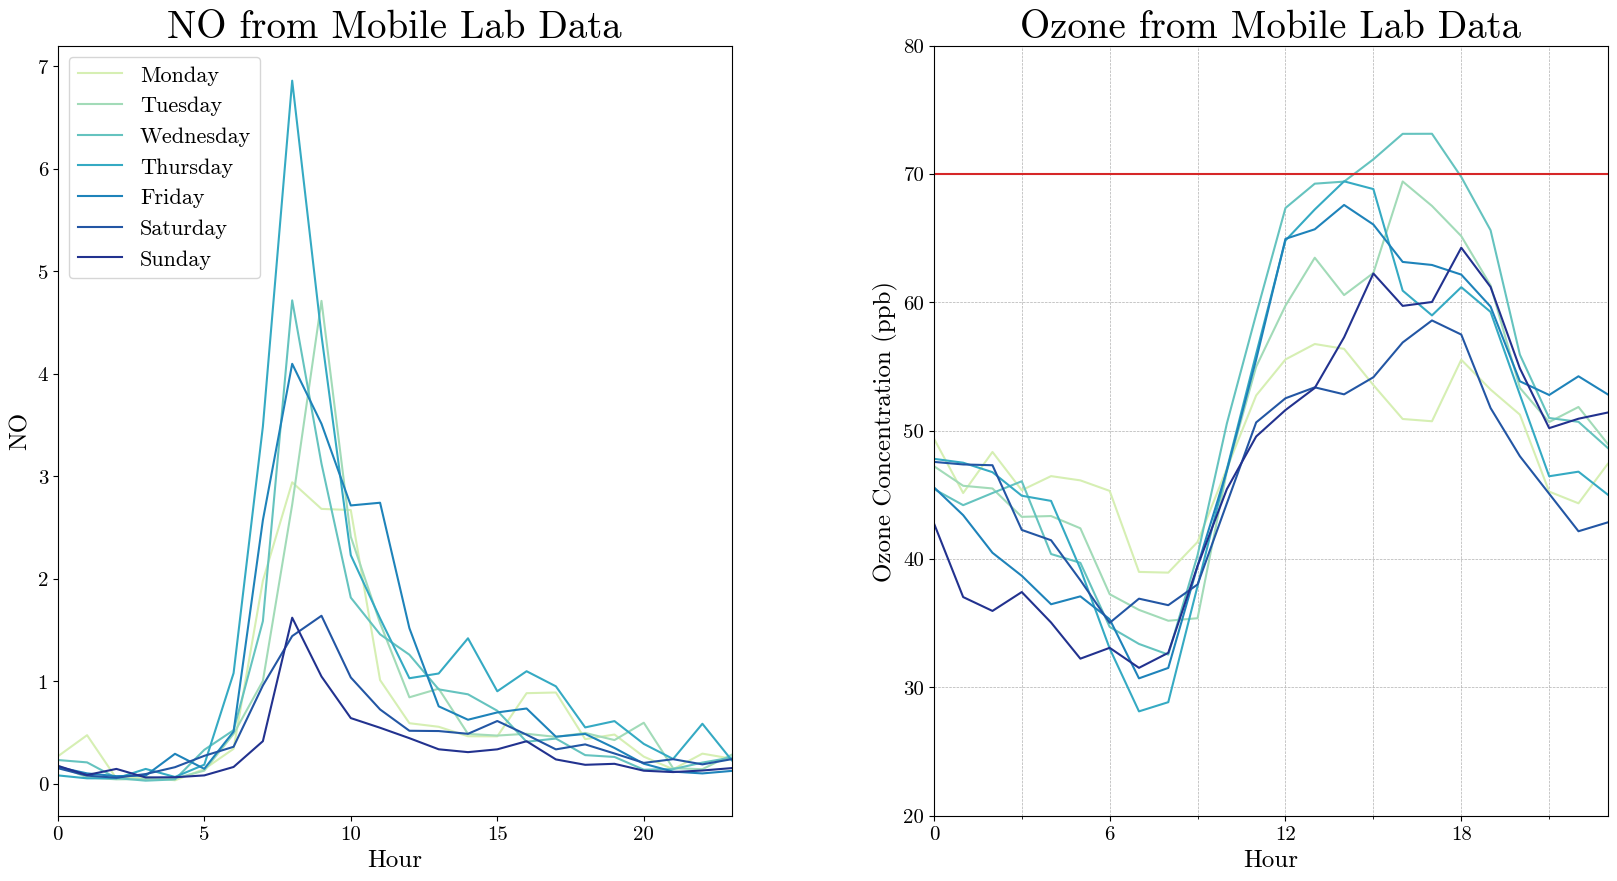

In [15]:
fig, ax = plt.subplots(1,2, figsize = (20,10))
color_values_week = np.linspace(0.2, 1, 8)
colormap1 = 'YlGnBu'
cmap1 = mpl.colormaps[colormap1]
for day_val in range(0,7):
    ax[0].plot(hour_range, day_of_week_no_ppbv_mean[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax[0].set_xlabel('Hour')
    ax[0].set_ylabel('NO')
    #ax[0].set_ylim([-0.25,1.5])
    ax[0].set_title('NO from Mobile Lab Data')

    ax[1].plot(hour_range, day_of_week_ozone_ppbv_mean_mobile_lab[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax[1].set_xlabel('Hour')
    ax[1].set_ylabel('Ozone Concentration (ppb)')
    ax[1].set_ylim([20,80])
    ax[1].set_title('Ozone from Mobile Lab Data' )
#ax[0].plot(hour_range, overall_nox_avg, color = 'k', label = 'Campaign Average')
#ax[0].fill_between(hour_range, overall_nox_avg - overall_nox_std, overall_nox_avg + overall_nox_std, color='k',alpha = 0.1)
ax1.xaxis.set_minor_locator(MultipleLocator(3))
ax1.xaxis.set_major_locator(MultipleLocator(6))
ax1.grid(which='both', linestyle='--', linewidth=0.5)

# box = ax[0].get_position()
# ax[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax[0].legend(loc='upper left')

#ax[1].plot(hour_range, o3_avg_from, color = 'k', label = 'Campaign Average')
#ax[1].fill_between(hour_range, o3_avg_from - o3_std_from, o3_avg_from + o3_std_from, color='k',alpha = 0.1)
ax[1].xaxis.set_minor_locator(MultipleLocator(3))
ax[1].xaxis.set_major_locator(MultipleLocator(6))
ax[1].grid(which='both', linestyle='--', linewidth=0.5)
ax[1].hlines(y=70, xmin = 0, xmax = 23, color = 'tab:red')
#plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/hawthorne_nox_ozone_day_of_week_comparison_' + merged_or_usos + '.png', dpi =300)
plt.show()

/tmp/ipykernel_3838838/2933867915.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(1,2, figsize = (20,10))


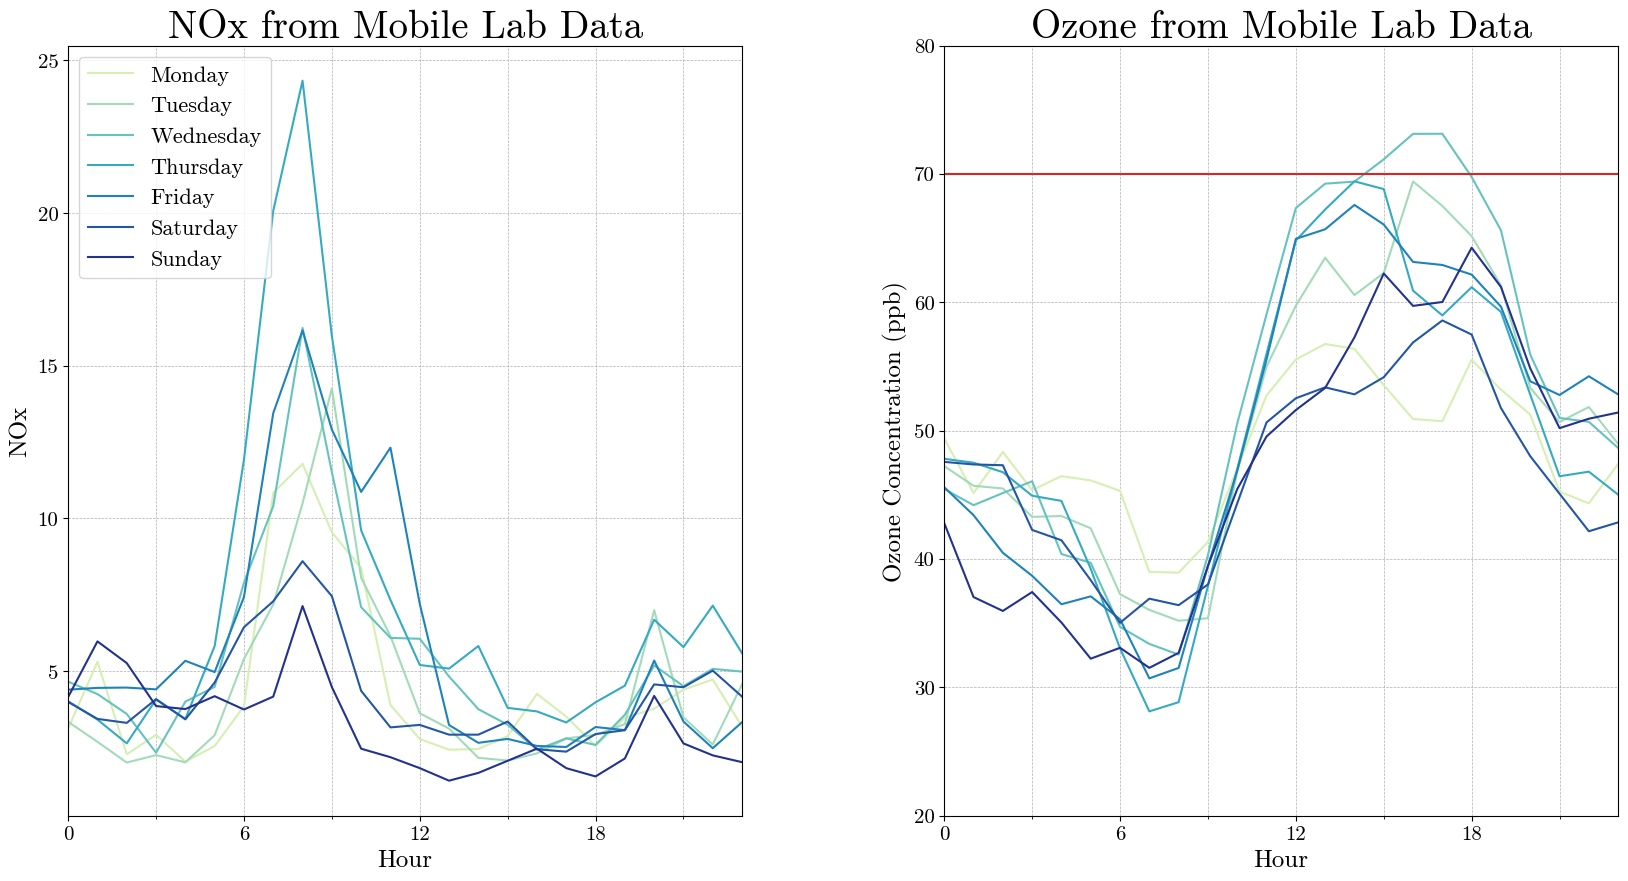

In [16]:
fig, ax = plt.subplots(1,2, figsize = (20,10))
color_values_week = np.linspace(0.2, 1, 8)
colormap1 = 'YlGnBu'
cmap1 = mpl.colormaps[colormap1]
for day_val in range(0,7):
    ax[0].plot(hour_range, day_of_week_nox_ppbv_mean[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax[0].set_xlabel('Hour')
    ax[0].set_ylabel('NOx')
    #ax[0].set_ylim([-0.25,1.5])
    ax[0].set_title('NOx from Mobile Lab Data')

    ax[1].plot(hour_range, day_of_week_ozone_ppbv_mean_mobile_lab[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax[1].set_xlabel('Hour')
    ax[1].set_ylabel('Ozone Concentration (ppb)')
    ax[1].set_ylim([20,80])
    ax[1].set_title('Ozone from Mobile Lab Data' )
#ax[0].plot(hour_range, overall_nox_avg, color = 'k', label = 'Campaign Average')
#ax[0].fill_between(hour_range, overall_nox_avg - overall_nox_std, overall_nox_avg + overall_nox_std, color='k',alpha = 0.1)
ax[0].xaxis.set_minor_locator(MultipleLocator(3))
ax[0].xaxis.set_major_locator(MultipleLocator(6))
ax[0].grid(which='both', linestyle='--', linewidth=0.5)

# box = ax[0].get_position()
# ax[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax[0].legend(loc='upper left')

#ax[1].plot(hour_range, o3_avg_from, color = 'k', label = 'Campaign Average')
#ax[1].fill_between(hour_range, o3_avg_from - o3_std_from, o3_avg_from + o3_std_from, color='k',alpha = 0.1)
ax[1].xaxis.set_minor_locator(MultipleLocator(3))
ax[1].xaxis.set_major_locator(MultipleLocator(6))
ax[1].grid(which='both', linestyle='--', linewidth=0.5)
ax[1].hlines(y=70, xmin = 0, xmax = 23, color = 'tab:red')
#plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/hawthorne_nox_ozone_day_of_week_comparison_' + merged_or_usos + '.png', dpi =300)
plt.show()

/tmp/ipykernel_3838838/978217032.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(1,2, figsize = (20,10))


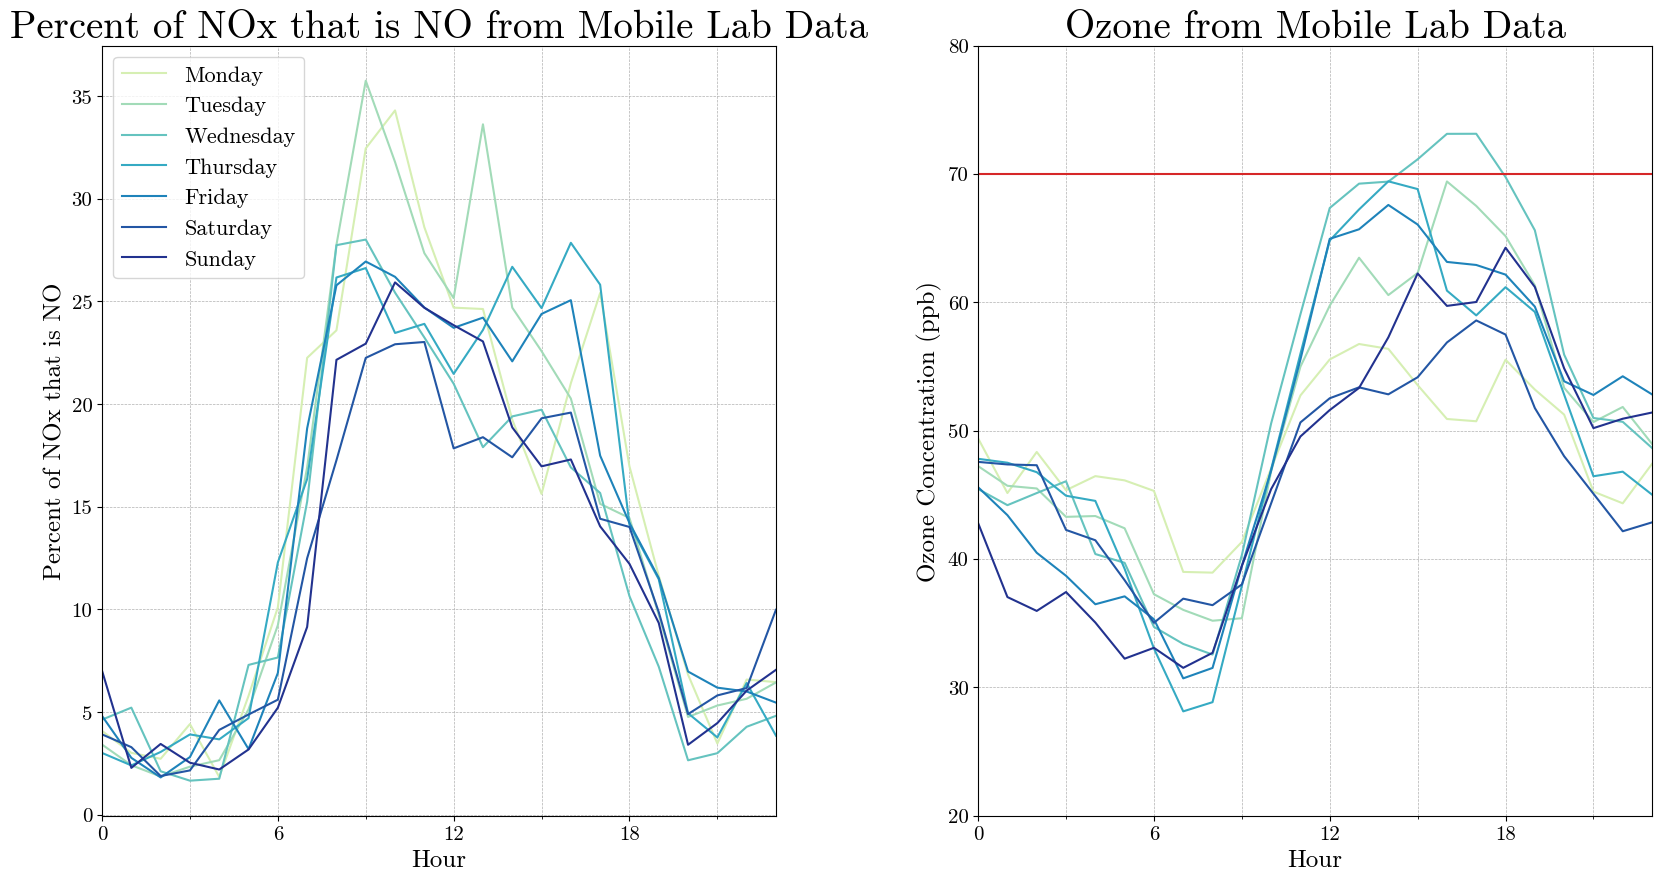

In [17]:
fig, ax = plt.subplots(1,2, figsize = (20,10))
color_values_week = np.linspace(0.2, 1, 8)
colormap1 = 'YlGnBu'
cmap1 = mpl.colormaps[colormap1]
for day_val in range(0,7):
    ax[0].plot(hour_range, day_of_week_percent_no_mean[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax[0].set_xlabel('Hour')
    ax[0].set_ylabel('Percent of NOx that is NO')
    #ax[0].set_ylim([-0.25,1.5])
    ax[0].set_title('Percent of NOx that is NO from Mobile Lab Data')

    ax[1].plot(hour_range, day_of_week_ozone_ppbv_mean_mobile_lab[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax[1].set_xlabel('Hour')
    ax[1].set_ylabel('Ozone Concentration (ppb)')
    ax[1].set_ylim([20,80])
    ax[1].set_title('Ozone from Mobile Lab Data' )
#ax[0].plot(hour_range, overall_nox_avg, color = 'k', label = 'Campaign Average')
#ax[0].fill_between(hour_range, overall_nox_avg - overall_nox_std, overall_nox_avg + overall_nox_std, color='k',alpha = 0.1)
ax[0].xaxis.set_minor_locator(MultipleLocator(3))
ax[0].xaxis.set_major_locator(MultipleLocator(6))
ax[0].grid(which='both', linestyle='--', linewidth=0.5)

# box = ax[0].get_position()
# ax[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax[0].legend(loc='upper left')

#ax[1].plot(hour_range, o3_avg_from, color = 'k', label = 'Campaign Average')
#ax[1].fill_between(hour_range, o3_avg_from - o3_std_from, o3_avg_from + o3_std_from, color='k',alpha = 0.1)
ax[1].xaxis.set_minor_locator(MultipleLocator(3))
ax[1].xaxis.set_major_locator(MultipleLocator(6))
ax[1].grid(which='both', linestyle='--', linewidth=0.5)
ax[1].hlines(y=70, xmin = 0, xmax = 23, color = 'tab:red')
#plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/hawthorne_nox_ozone_day_of_week_comparison_' + merged_or_usos + '.png', dpi =300)
plt.show()

/tmp/ipykernel_3838838/1573722784.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(1,2, figsize = (20,10))


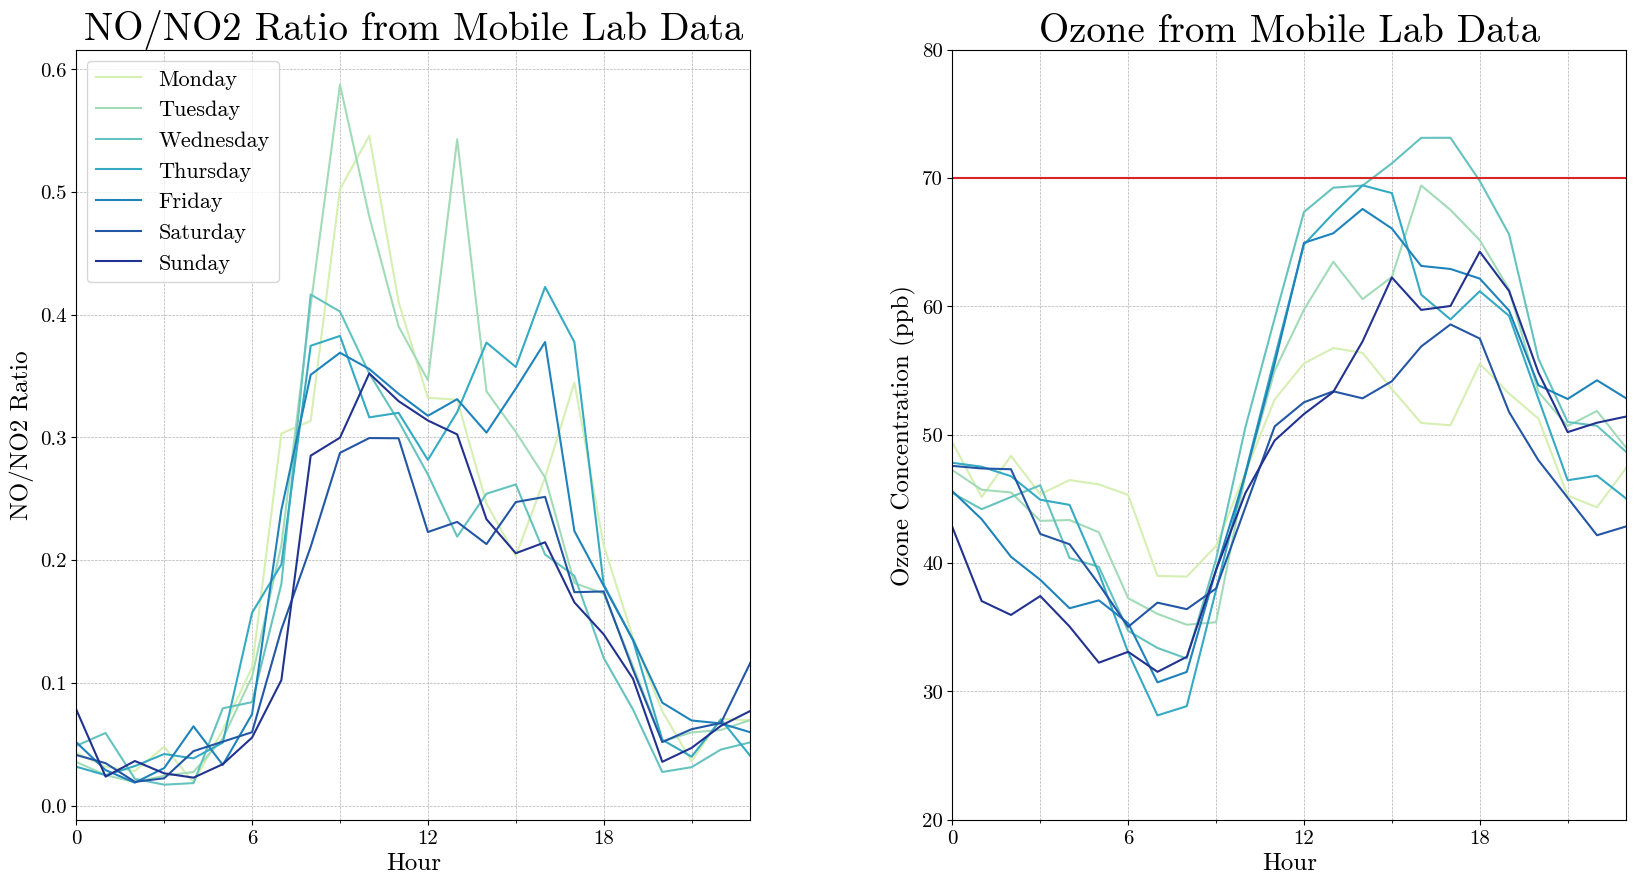

In [18]:
fig, ax = plt.subplots(1,2, figsize = (20,10))
color_values_week = np.linspace(0.2, 1, 8)
colormap1 = 'YlGnBu'
cmap1 = mpl.colormaps[colormap1]
for day_val in range(0,7):
    ax[0].plot(hour_range, day_of_week_no_no2_ratio[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax[0].set_xlabel('Hour')
    ax[0].set_ylabel('NO/NO2 Ratio')
    #ax[0].set_ylim([-0.25,1.5])
    ax[0].set_title('NO/NO2 Ratio from Mobile Lab Data')

    ax[1].plot(hour_range, day_of_week_ozone_ppbv_mean_mobile_lab[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax[1].set_xlabel('Hour')
    ax[1].set_ylabel('Ozone Concentration (ppb)')
    ax[1].set_ylim([20,80])
    ax[1].set_title('Ozone from Mobile Lab Data' )
#ax[0].plot(hour_range, overall_nox_avg, color = 'k', label = 'Campaign Average')
#ax[0].fill_between(hour_range, overall_nox_avg - overall_nox_std, overall_nox_avg + overall_nox_std, color='k',alpha = 0.1)
ax[0].xaxis.set_minor_locator(MultipleLocator(3))
ax[0].xaxis.set_major_locator(MultipleLocator(6))
ax[0].grid(which='both', linestyle='--', linewidth=0.5)

# box = ax[0].get_position()
# ax[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax[0].legend(loc='upper left')

#ax[1].plot(hour_range, o3_avg_from, color = 'k', label = 'Campaign Average')
#ax[1].fill_between(hour_range, o3_avg_from - o3_std_from, o3_avg_from + o3_std_from, color='k',alpha = 0.1)
ax[1].xaxis.set_minor_locator(MultipleLocator(3))
ax[1].xaxis.set_major_locator(MultipleLocator(6))
ax[1].grid(which='both', linestyle='--', linewidth=0.5)
ax[1].hlines(y=70, xmin = 0, xmax = 23, color = 'tab:red')
#plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/hawthorne_nox_ozone_day_of_week_comparison_' + merged_or_usos + '.png', dpi =300)
plt.show()

/tmp/ipykernel_3838838/4038177829.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, (ax1, ax2) = plt.subplots(1,2, figsize = (20,10), layout='tight')


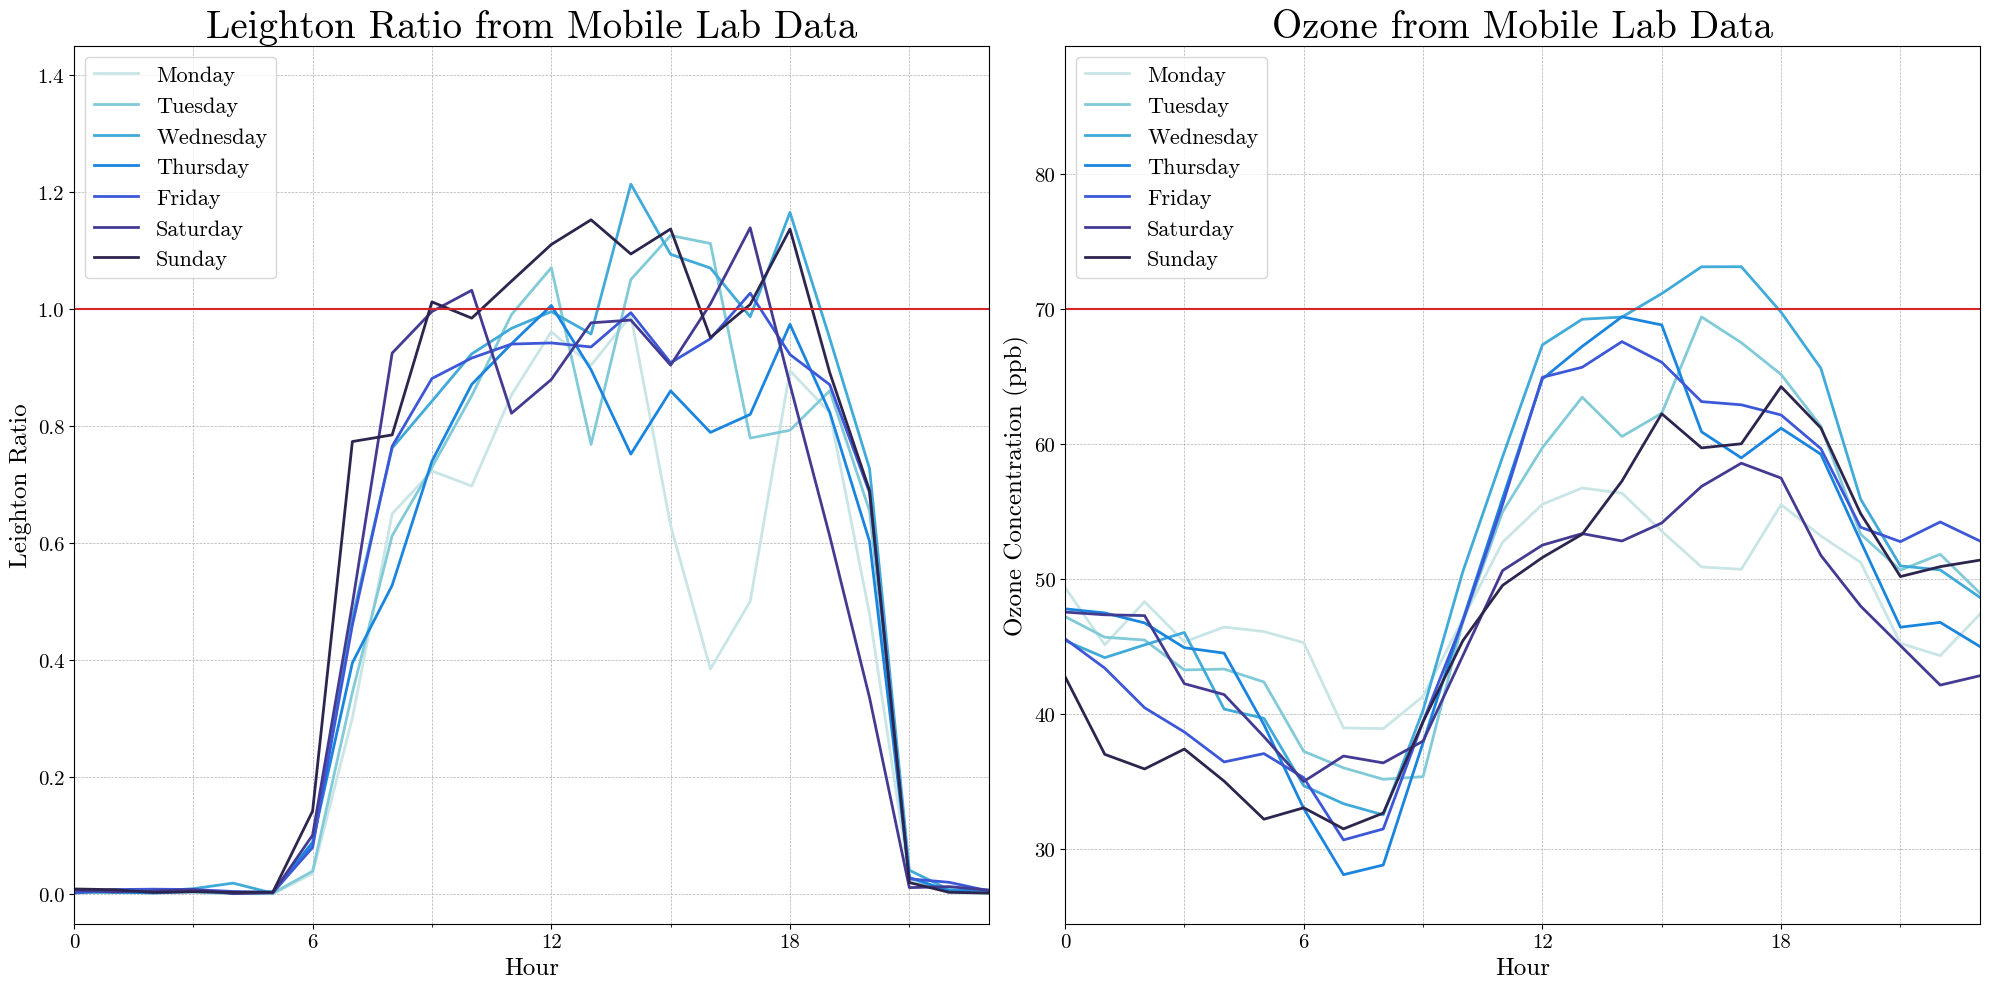

In [19]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (20,10), layout='tight')
plt.rcParams['figure.figsize'] = [1.618 * i for i in plt.rcParams['figure.figsize']]
plt.rcParams['figure.subplot.wspace'] = 0.3

colors = cmr.take_cmap_colors('cmr.freeze_r', 7, cmap_range=(0.1, 0.8), return_fmt='hex')

for day_val in range(0,7):
    ax1.plot(hour_range, day_of_week_leighton_ratio_mean[days_of_week[day_val]], 
             color=colors[day_val], label = days_of_week[day_val], linewidth = 2)
    ax1.set_xlabel('Hour')
    ax1.set_ylabel('Leighton Ratio')
    ax1.set_title('Leighton Ratio from Mobile Lab Data')

    ax2.plot(hour_range, day_of_week_ozone_ppbv_mean_mobile_lab[days_of_week[day_val]], 
             color=colors[day_val], label = days_of_week[day_val], linewidth = 2)
    ax2.set_xlabel('Hour')
    ax2.set_ylabel('Ozone Concentration (ppb)')
    ax2.set_title('Ozone from Mobile Lab Data' )

#Plot average, standard deviation, red line thresholds
# ax1.plot(hour_range, overall_leighton_ratio_avg_mobile_lab, color = 'k', label = 'Campaign Average')
# ax1.fill_between(hour_range, overall_leighton_ratio_avg_mobile_lab - overall_leighton_ratio_std_mobile_lab, 
#                  overall_leighton_ratio_avg_mobile_lab + overall_leighton_ratio_std_mobile_lab, color='k',alpha = 0.1)

ax1.hlines(y=1.0, xmin = 0, xmax = 23, color = 'tab:red')

# ax2.plot(hour_range, overall_ozone_avg_mobile_lab, color = 'k', label = 'Campaign Average')
# ax2.fill_between(hour_range, overall_ozone_avg_mobile_lab - overall_ozone_std_mobile_lab, 
#                  overall_ozone_avg_mobile_lab + overall_ozone_std_mobile_lab, color='k',alpha = 0.1)

ax2.hlines(y=70, xmin = 0, xmax = 23, color = 'tab:red')

#Align the left subplot to the right subplot at 1.0 for the Leighton Ratio and 70 ppbv for the ozone
align_fraction = 0.70 #where to align, 60% of the way to the top of the plot
align_value_leighton = 1.0
align_value_ozone = 70

#values that the y-axis should span
span_leighton = 1.5
span_ozone = 65

# Left subplot ylim
ymin_leighton = align_value_leighton - align_fraction * span_leighton
ymax_leighton = ymin_leighton + span_leighton
ax1.set_ylim(ymin_leighton, ymax_leighton)

# Right subplot ylim
ymin_ozone = align_value_ozone - align_fraction * span_ozone
ymax_ozone = ymin_ozone + span_ozone
ax2.set_ylim(ymin_ozone, ymax_ozone)

ax1.legend(loc='upper left')
ax2.legend(loc='upper left')

#set ticks
ax1.xaxis.set_minor_locator(MultipleLocator(3))
ax1.xaxis.set_major_locator(MultipleLocator(6))
ax1.grid(which='both', linestyle='--', linewidth=0.5)

ax2.xaxis.set_minor_locator(MultipleLocator(3))
ax2.xaxis.set_major_locator(MultipleLocator(6))
ax2.grid(which='both', linestyle='--', linewidth=0.5)

plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/hawthorne_leighton_ratio_ozone_day_of_week_comparison_mobile_lab.png', dpi =150)
plt.show()

/tmp/ipykernel_3838838/3336424717.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax1 = plt.subplots(1,1, figsize = (10,10), layout='tight')


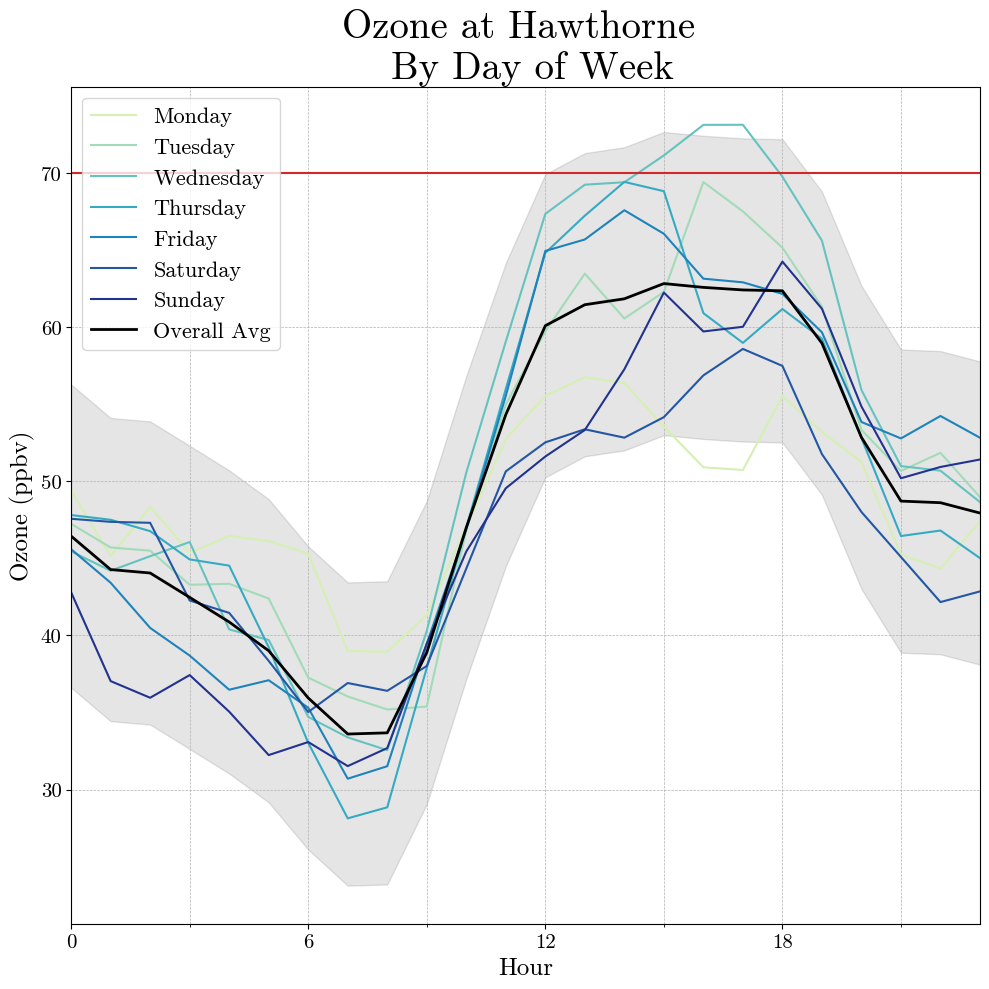

In [20]:
fig, ax1 = plt.subplots(1,1, figsize = (10,10), layout='tight')
plt.rcParams['figure.figsize'] = [1.618 * i for i in plt.rcParams['figure.figsize']]
colors = cmr.take_cmap_colors('cmr.freeze_r', 7, cmap_range=(0.1, 0.8), return_fmt='hex')

for day_val in range(0,7):
    ax1.plot(hour_range, day_of_week_ozone_ppbv_mean_mobile_lab[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax1.set_xlabel('Hour')
    ax1.set_ylabel('Ozone (ppbv)')
    #ax[0].set_ylim([-0.25,1.5])
    ax1.set_title('Ozone at Hawthorne \n By Day of Week')

plt.hlines(y=70, xmin = 0, xmax = 23, color = 'tab:red')
plt.plot(hour_range, overall_ozone_avg_mobile_lab, linestyle='solid', linewidth=2, color='k', label = 'Overall Avg')
plt.fill_between(hour_range, overall_ozone_avg_mobile_lab - overall_ozone_std_mobile_lab, 
                     overall_ozone_avg_mobile_lab + overall_ozone_std_mobile_lab, color='k',alpha = 0.1)

ax1.xaxis.set_minor_locator(MultipleLocator(3))
ax1.xaxis.set_major_locator(MultipleLocator(6))
ax1.grid(which='both', linestyle='--', linewidth=0.5)

ax1.legend(loc='upper left')

ax1.xaxis.set_minor_locator(MultipleLocator(3))
ax1.xaxis.set_major_locator(MultipleLocator(6))
ax1.grid(which='both', linestyle='--', linewidth=0.5)
plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/ozone_mixing_ratio_day_of_week_mobile_lab.png', dpi =150)
plt.show()

/tmp/ipykernel_3838838/1167334025.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax1 = plt.subplots(1,1, figsize = (10,10), layout='tight')


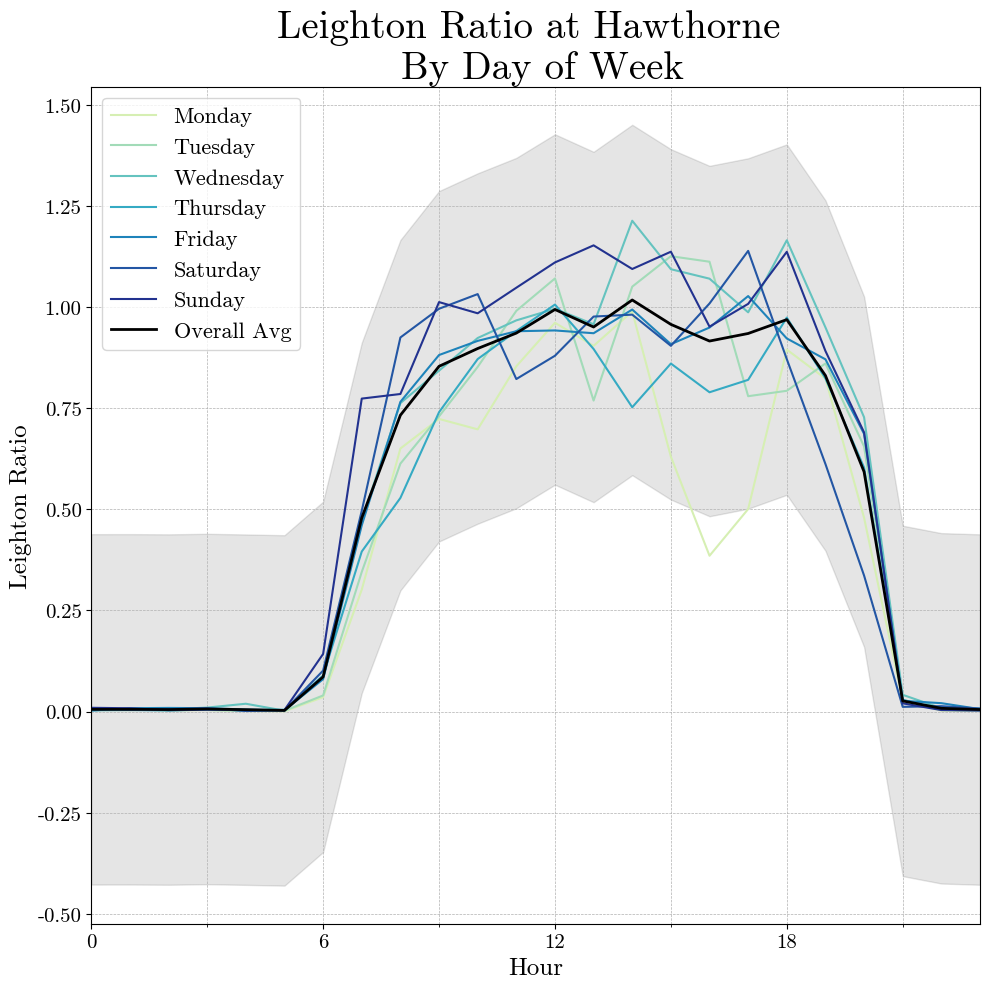

In [21]:
fig, ax1 = plt.subplots(1,1, figsize = (10,10), layout='tight')
plt.rcParams['figure.figsize'] = [1.618 * i for i in plt.rcParams['figure.figsize']]
colors = cmr.take_cmap_colors('cmr.freeze_r', 7, cmap_range=(0.1, 0.8), return_fmt='hex')

for day_val in range(0,7):
    ax1.plot(hour_range, day_of_week_leighton_ratio_mean[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax1.set_xlabel('Hour')
    ax1.set_ylabel('Leighton Ratio')
    #ax[0].set_ylim([-0.25,1.5])
    ax1.set_title('Leighton Ratio at Hawthorne \n By Day of Week')

plt.plot(hour_range, overall_leighton_ratio_avg_mobile_lab, linestyle='solid', linewidth=2, color='k', label = 'Overall Avg')
plt.fill_between(hour_range, overall_leighton_ratio_avg_mobile_lab - overall_leighton_ratio_std_mobile_lab, 
                     overall_leighton_ratio_avg_mobile_lab + overall_leighton_ratio_std_mobile_lab, color='k',alpha = 0.1)

ax1.xaxis.set_minor_locator(MultipleLocator(3))
ax1.xaxis.set_major_locator(MultipleLocator(6))
ax1.grid(which='both', linestyle='--', linewidth=0.5)

ax1.legend(loc='upper left')

ax1.xaxis.set_minor_locator(MultipleLocator(3))
ax1.xaxis.set_major_locator(MultipleLocator(6))
ax1.grid(which='both', linestyle='--', linewidth=0.5)
plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/leighton_ratio_day_of_week_mobile_lab.png', dpi =150)
plt.show()

/tmp/ipykernel_3838838/930261768.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax1 = plt.subplots(1,1, figsize = (10,10), layout='tight')


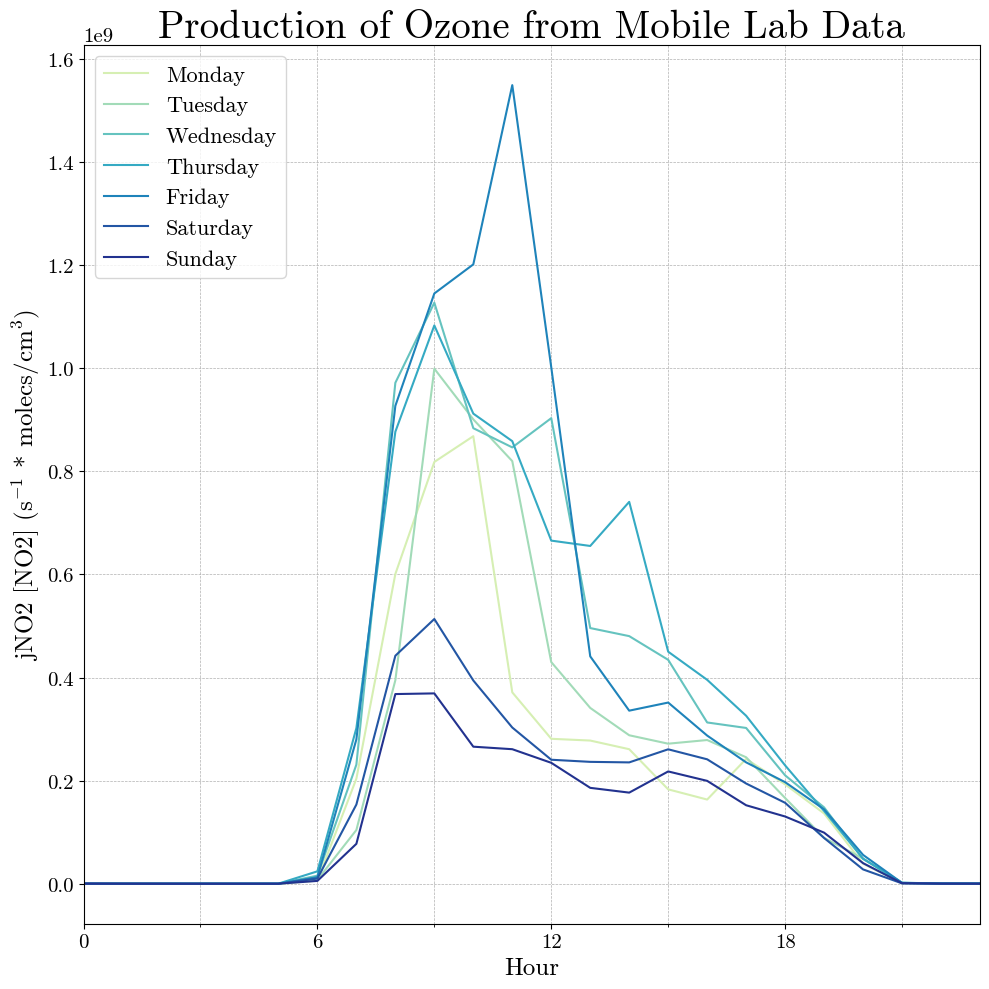

In [22]:
fig, ax1 = plt.subplots(1,1, figsize = (10,10), layout='tight')
plt.rcParams['figure.figsize'] = [1.618 * i for i in plt.rcParams['figure.figsize']]
plt.rcParams['figure.subplot.wspace'] = 0.3
colors = cmr.take_cmap_colors('cmr.freeze_r', 7, cmap_range=(0.1, 0.8), return_fmt='hex')

for day_val in range(0,7):
    ax1.plot(hour_range, day_of_week_prod_o3_num_mean[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax1.set_xlabel('Hour')
    ax1.set_ylabel('jNO2 [NO2] (s$^{-1}$ * molecs/cm$^3$)')
    #ax[0].set_ylim([-0.25,1.5])
    ax1.set_title('Production of Ozone from Mobile Lab Data')

ax1.xaxis.set_minor_locator(MultipleLocator(3))
ax1.xaxis.set_major_locator(MultipleLocator(6))
ax1.grid(which='both', linestyle='--', linewidth=0.5)

ax1.legend(loc='upper left')

ax1.xaxis.set_minor_locator(MultipleLocator(3))
ax1.xaxis.set_major_locator(MultipleLocator(6))
ax1.grid(which='both', linestyle='--', linewidth=0.5)
plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/prod_ozone_day_of_week_mobile_lab.png', dpi =150)
plt.show()

/tmp/ipykernel_3838838/1003716793.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax1 = plt.subplots(1,1, figsize = (10,10), layout='tight')


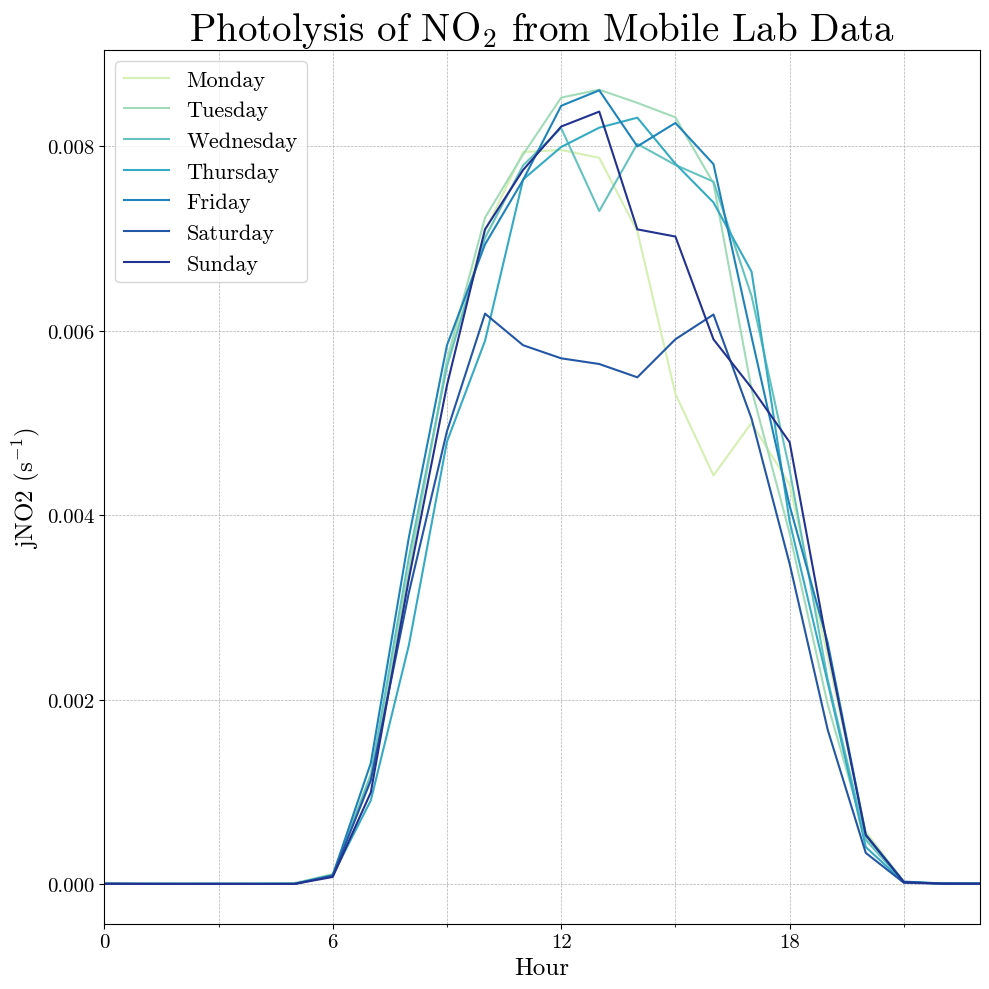

In [23]:
fig, ax1 = plt.subplots(1,1, figsize = (10,10), layout='tight')
plt.rcParams['figure.figsize'] = [1.618 * i for i in plt.rcParams['figure.figsize']]
plt.rcParams['figure.subplot.wspace'] = 0.3
colors = cmr.take_cmap_colors('cmr.freeze_r', 7, cmap_range=(0.1, 0.8), return_fmt='hex')

for day_val in range(0,7):
    ax1.plot(hour_range, day_of_week_no2_photolysis[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax1.set_xlabel('Hour')
    ax1.set_ylabel('jNO2 (s$^{-1}$)')
    #ax[0].set_ylim([-0.25,1.5])
    ax1.set_title('Photolysis of NO$_2$ from Mobile Lab Data')

ax1.xaxis.set_minor_locator(MultipleLocator(3))
ax1.xaxis.set_major_locator(MultipleLocator(6))
ax1.grid(which='both', linestyle='--', linewidth=0.5)

ax1.legend(loc='upper left')

ax1.xaxis.set_minor_locator(MultipleLocator(3))
ax1.xaxis.set_major_locator(MultipleLocator(6))
ax1.grid(which='both', linestyle='--', linewidth=0.5)
plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/photolysis_no2_day_of_week_mobile_lab.png', dpi =150)
plt.show()

/tmp/ipykernel_3838838/3890402886.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax1 = plt.subplots(1,1, figsize = (10,10), layout='tight')


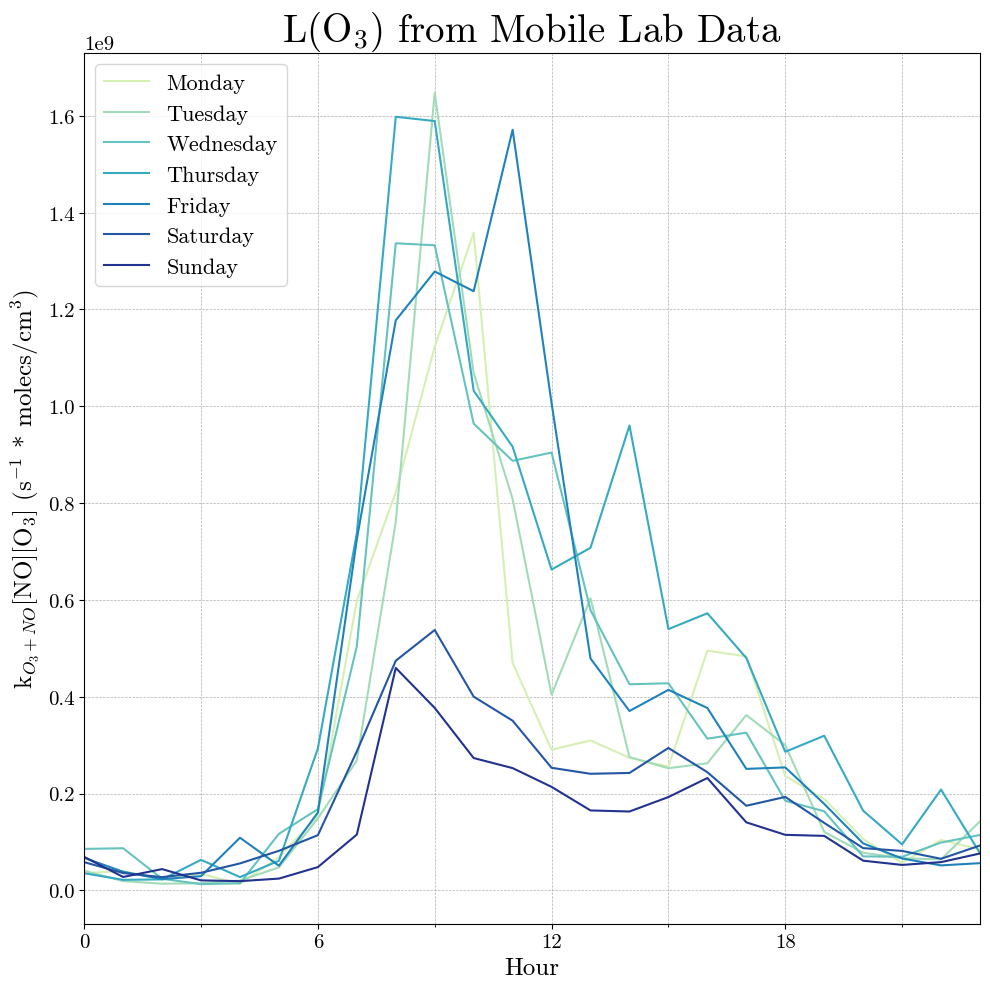

In [24]:
fig, ax1 = plt.subplots(1,1, figsize = (10,10), layout='tight')
plt.rcParams['figure.figsize'] = [1.618 * i for i in plt.rcParams['figure.figsize']]
plt.rcParams['figure.subplot.wspace'] = 0.3
colors = cmr.take_cmap_colors('cmr.freeze_r', 7, cmap_range=(0.1, 0.8), return_fmt='hex')

for day_val in range(0,7):
    ax1.plot(hour_range, day_of_week_loss_o3_den_mean[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax1.set_xlabel('Hour')
    ax1.set_ylabel('k$_{O_3+NO}$[NO][O$_3$] (s$^{-1}$ * molecs/cm$^3$)')
    #ax[0].set_ylim([-0.25,1.5])
    ax1.set_title('L(O$_3$) from Mobile Lab Data')

ax1.xaxis.set_minor_locator(MultipleLocator(3))
ax1.xaxis.set_major_locator(MultipleLocator(6))
ax1.grid(which='both', linestyle='--', linewidth=0.5)

ax1.legend(loc='upper left')

ax1.xaxis.set_minor_locator(MultipleLocator(3))
ax1.xaxis.set_major_locator(MultipleLocator(6))
ax1.grid(which='both', linestyle='--', linewidth=0.5)
plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/ozone_loss_day_of_week_mobile_lab.png', dpi =150)
plt.show()

/tmp/ipykernel_3838838/2239387323.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(1,2, figsize = (20,10))


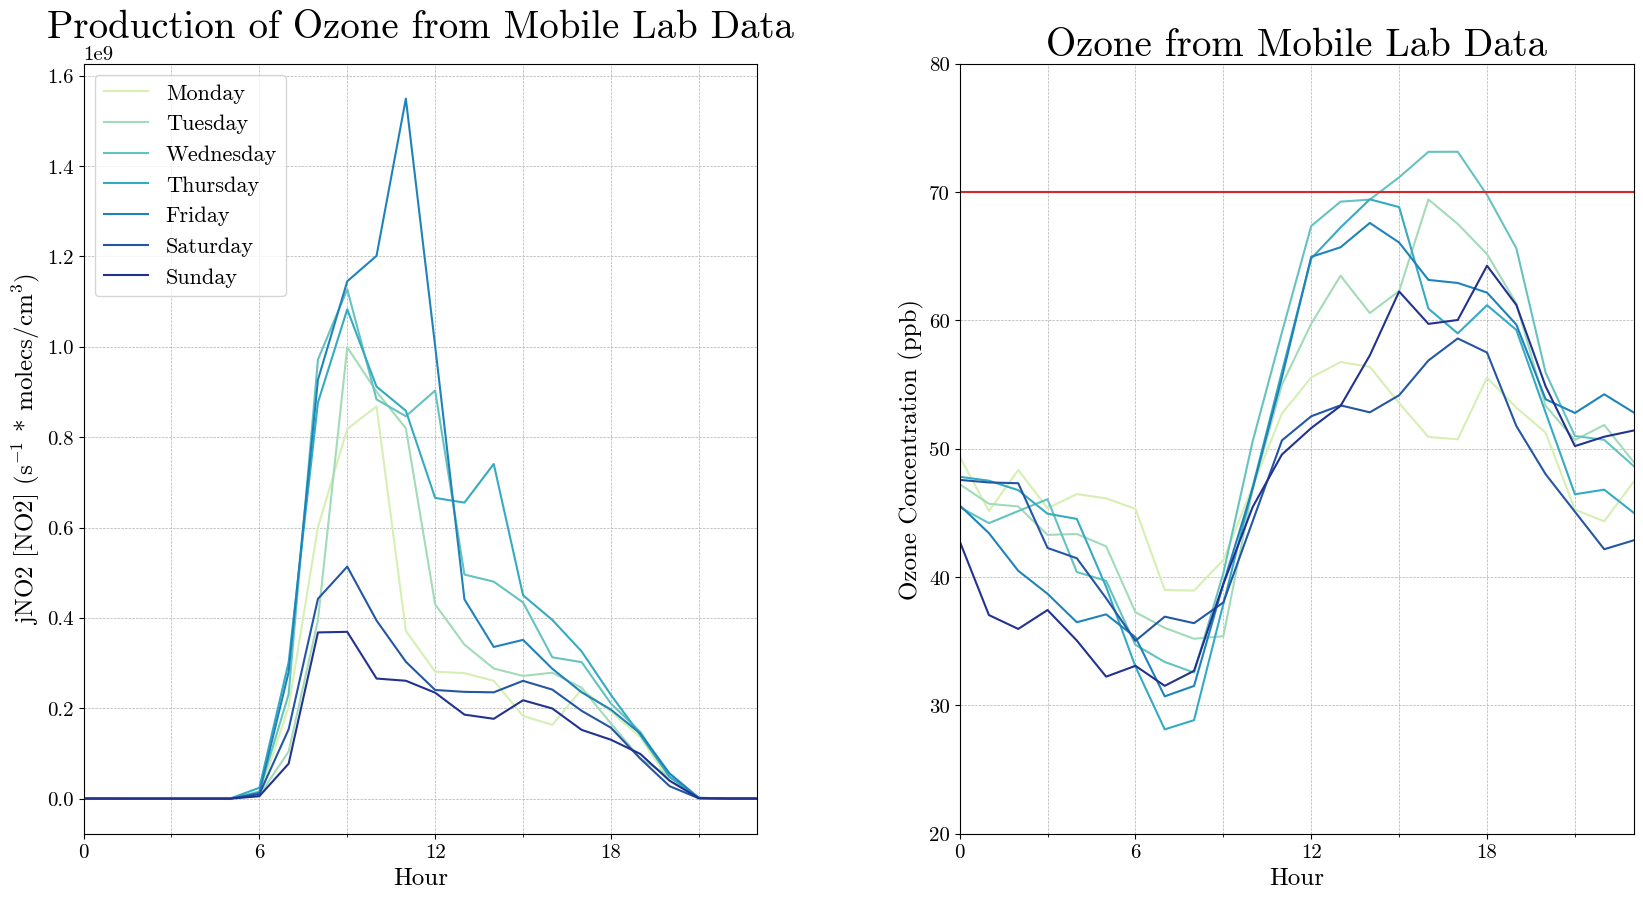

In [25]:
fig, ax = plt.subplots(1,2, figsize = (20,10))
color_values_week = np.linspace(0.2, 1, 8)
colormap1 = 'YlGnBu'
cmap1 = mpl.colormaps[colormap1]
for day_val in range(0,7):
    ax[0].plot(hour_range, day_of_week_prod_o3_num_mean[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax[0].set_xlabel('Hour')
    ax[0].set_ylabel('jNO2 [NO2] (s$^{-1}$ * molecs/cm$^3$)')
    #ax[0].set_ylim([-0.25,1.5])
    ax[0].set_title('Production of Ozone from Mobile Lab Data')

    ax[1].plot(hour_range, day_of_week_ozone_ppbv_mean_mobile_lab[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax[1].set_xlabel('Hour')
    ax[1].set_ylabel('Ozone Concentration (ppb)')
    ax[1].set_ylim([20,80])
    ax[1].set_title('Ozone from Mobile Lab Data' )
#ax[0].plot(hour_range, overall_nox_avg, color = 'k', label = 'Campaign Average')
#ax[0].fill_between(hour_range, overall_nox_avg - overall_nox_std, overall_nox_avg + overall_nox_std, color='k',alpha = 0.1)
ax[0].xaxis.set_minor_locator(MultipleLocator(3))
ax[0].xaxis.set_major_locator(MultipleLocator(6))
ax[0].grid(which='both', linestyle='--', linewidth=0.5)

# box = ax[0].get_position()
# ax[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax[0].legend(loc='upper left')

#ax[1].plot(hour_range, o3_avg_from, color = 'k', label = 'Campaign Average')
#ax[1].fill_between(hour_range, o3_avg_from - o3_std_from, o3_avg_from + o3_std_from, color='k',alpha = 0.1)
ax[1].xaxis.set_minor_locator(MultipleLocator(3))
ax[1].xaxis.set_major_locator(MultipleLocator(6))
ax[1].grid(which='both', linestyle='--', linewidth=0.5)
ax[1].hlines(y=70, xmin = 0, xmax = 23, color = 'tab:red')
#plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/hawthorne_nox_ozone_day_of_week_comparison_' + merged_or_usos + '.png', dpi =300)
plt.show()

/tmp/ipykernel_3838838/2983281434.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(1,2, figsize = (20,10))


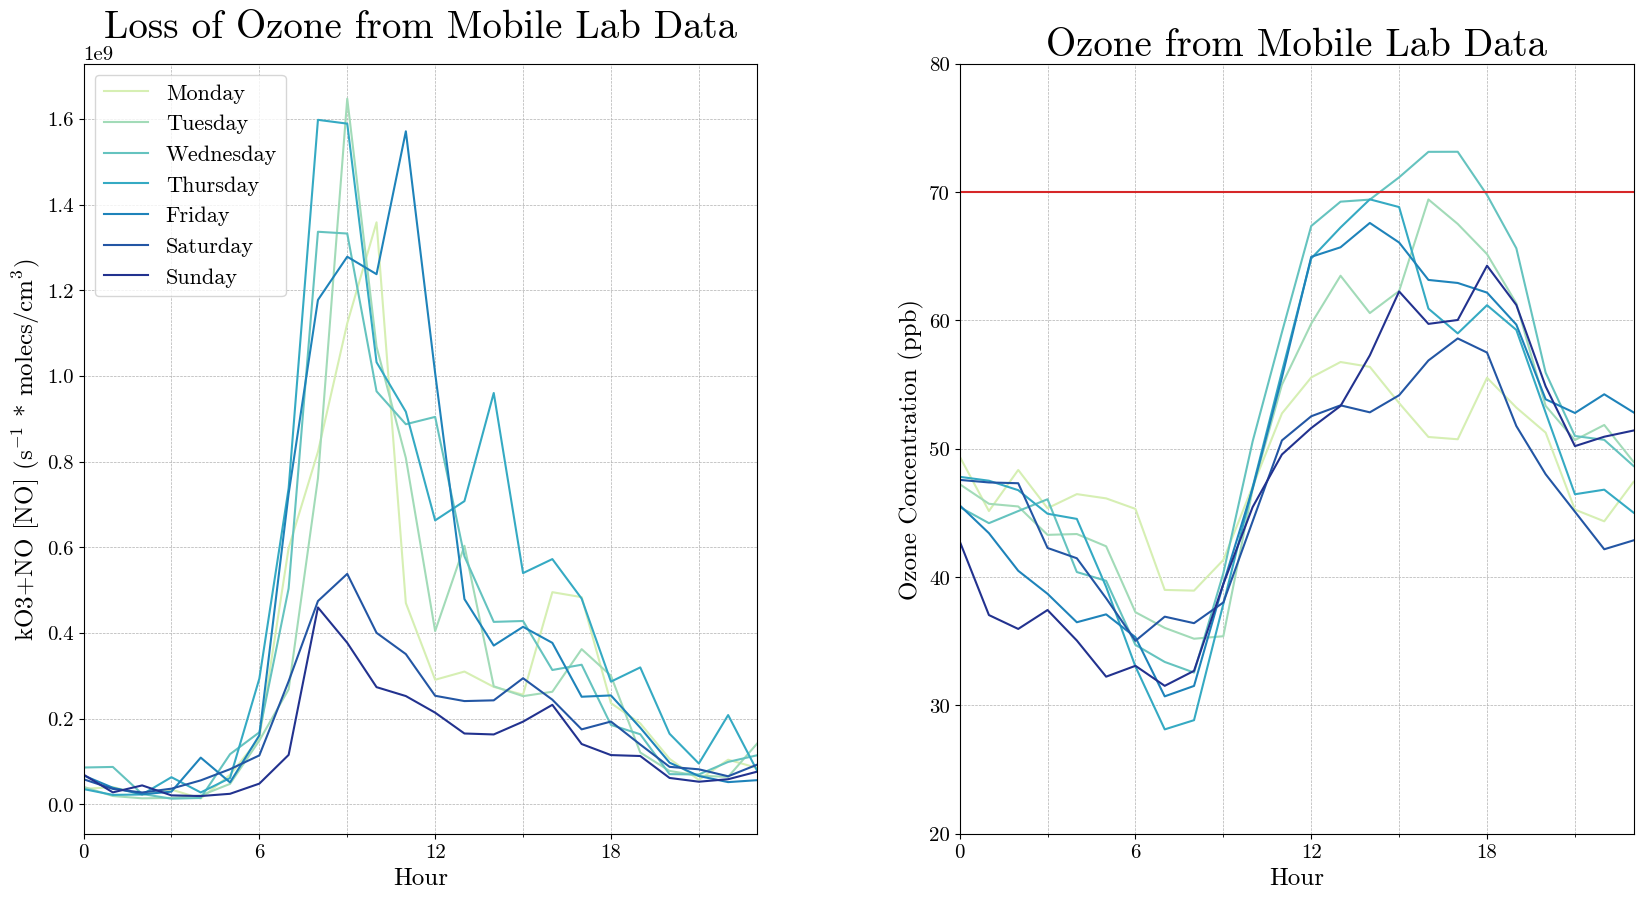

In [26]:
fig, ax = plt.subplots(1,2, figsize = (20,10))
color_values_week = np.linspace(0.2, 1, 8)
colormap1 = 'YlGnBu'
cmap1 = mpl.colormaps[colormap1]
for day_val in range(0,7):
    ax[0].plot(hour_range, day_of_week_loss_o3_den_mean[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax[0].set_xlabel('Hour')
    ax[0].set_ylabel('kO3+NO [NO] (s$^{-1}$ * molecs/cm$^3$)')
    #ax[0].set_ylim([-0.25,1.5])
    ax[0].set_title('Loss of Ozone from Mobile Lab Data')

    ax[1].plot(hour_range, day_of_week_ozone_ppbv_mean_mobile_lab[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax[1].set_xlabel('Hour')
    ax[1].set_ylabel('Ozone Concentration (ppb)')
    ax[1].set_ylim([20,80])
    ax[1].set_title('Ozone from Mobile Lab Data' )
#ax[0].plot(hour_range, overall_nox_avg, color = 'k', label = 'Campaign Average')
#ax[0].fill_between(hour_range, overall_nox_avg - overall_nox_std, overall_nox_avg + overall_nox_std, color='k',alpha = 0.1)
ax[0].xaxis.set_minor_locator(MultipleLocator(3))
ax[0].xaxis.set_major_locator(MultipleLocator(6))
ax[0].grid(which='both', linestyle='--', linewidth=0.5)

# box = ax[0].get_position()
# ax[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax[0].legend(loc='upper left')

#ax[1].plot(hour_range, o3_avg_from, color = 'k', label = 'Campaign Average')
#ax[1].fill_between(hour_range, o3_avg_from - o3_std_from, o3_avg_from + o3_std_from, color='k',alpha = 0.1)
ax[1].xaxis.set_minor_locator(MultipleLocator(3))
ax[1].xaxis.set_major_locator(MultipleLocator(6))
ax[1].grid(which='both', linestyle='--', linewidth=0.5)
ax[1].hlines(y=70, xmin = 0, xmax = 23, color = 'tab:red')
#plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/hawthorne_nox_ozone_day_of_week_comparison_' + merged_or_usos + '.png', dpi =300)
plt.show()

/tmp/ipykernel_3838838/555946055.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(1,2, figsize = (20,10))


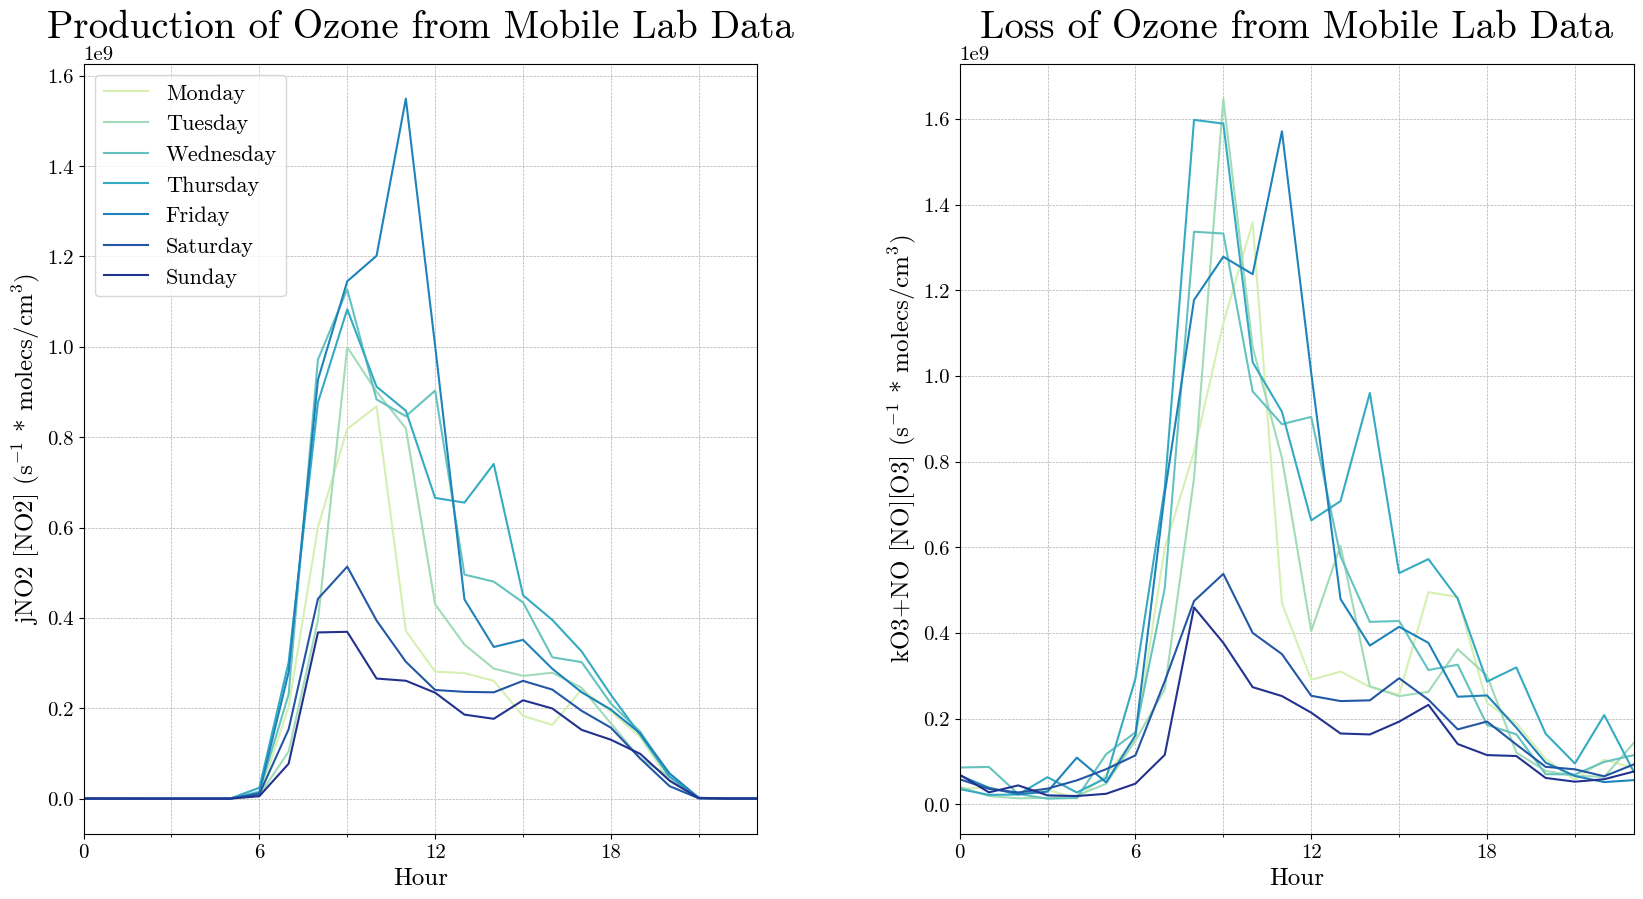

In [27]:
fig, ax = plt.subplots(1,2, figsize = (20,10))
color_values_week = np.linspace(0.2, 1, 8)
colormap1 = 'YlGnBu'
cmap1 = mpl.colormaps[colormap1]
for day_val in range(0,7):
    ax[0].plot(hour_range, day_of_week_prod_o3_num_mean[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax[0].set_xlabel('Hour')
    ax[0].set_ylabel('jNO2 [NO2] (s$^{-1}$ * molecs/cm$^3$)')
    #ax[0].set_ylim([-0.25,1.5])
    ax[0].set_title('Production of Ozone from Mobile Lab Data')

    ax[1].plot(hour_range, day_of_week_loss_o3_den_mean[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax[1].set_xlabel('Hour')
    ax[1].set_ylabel('kO3+NO [NO][O3] (s$^{-1}$ * molecs/cm$^3$)')
    #ax[1].set_ylim([20,80])
    ax[1].set_title('Loss of Ozone from Mobile Lab Data' )
#ax[0].plot(hour_range, overall_nox_avg, color = 'k', label = 'Campaign Average')
#ax[0].fill_between(hour_range, overall_nox_avg - overall_nox_std, overall_nox_avg + overall_nox_std, color='k',alpha = 0.1)
ax[0].xaxis.set_minor_locator(MultipleLocator(3))
ax[0].xaxis.set_major_locator(MultipleLocator(6))
ax[0].grid(which='both', linestyle='--', linewidth=0.5)

# box = ax[0].get_position()
# ax[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax[0].legend(loc='upper left')

#ax[1].plot(hour_range, o3_avg_from, color = 'k', label = 'Campaign Average')
#ax[1].fill_between(hour_range, o3_avg_from - o3_std_from, o3_avg_from + o3_std_from, color='k',alpha = 0.1)
ax[1].xaxis.set_minor_locator(MultipleLocator(3))
ax[1].xaxis.set_major_locator(MultipleLocator(6))
ax[1].grid(which='both', linestyle='--', linewidth=0.5)
#ax[1].hlines(y=70, xmin = 0, xmax = 23, color = 'tab:red')
#plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/hawthorne_nox_ozone_day_of_week_comparison_' + merged_or_usos + '.png', dpi =300)
plt.show()

/tmp/ipykernel_3838838/3841434233.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(2,2, figsize = (20,10))


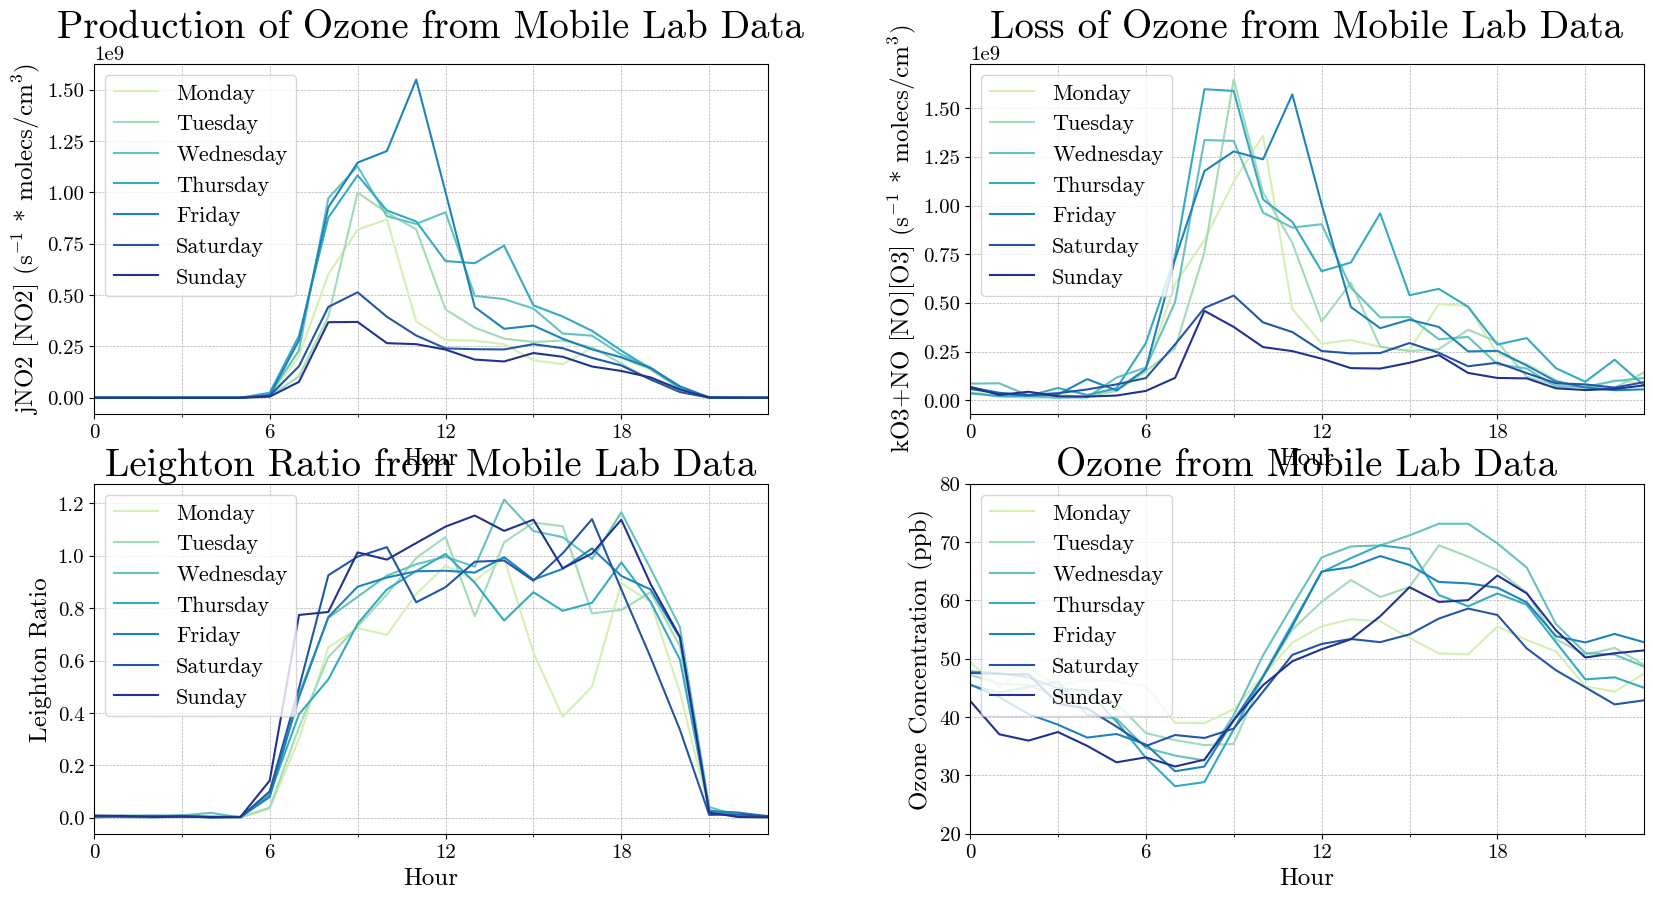

In [28]:
fig, ax = plt.subplots(2,2, figsize = (20,10))
color_values_week = np.linspace(0.2, 1, 8)
colormap1 = 'YlGnBu'
cmap1 = mpl.colormaps[colormap1]
for day_val in range(0,7):
    ax[0, 0].plot(hour_range, day_of_week_prod_o3_num_mean[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax[0, 0].set_xlabel('Hour')
    ax[0, 0].set_ylabel('jNO2 [NO2] (s$^{-1}$ * molecs/cm$^3$)')
    #ax[0].set_ylim([-0.25,1.5])
    ax[0, 0].set_title('Production of Ozone from Mobile Lab Data')

    ax[0, 1].plot(hour_range, day_of_week_loss_o3_den_mean[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax[0, 1].set_xlabel('Hour')
    ax[0, 1].set_ylabel('kO3+NO [NO][O3] (s$^{-1}$ * molecs/cm$^3$)')
    #ax[1].set_ylim([20,80])
    ax[0, 1].set_title('Loss of Ozone from Mobile Lab Data' )

    ax[1, 0].plot(hour_range, day_of_week_leighton_ratio_mean[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax[1, 0].set_xlabel('Hour')
    ax[1, 0].set_ylabel('Leighton Ratio')
    #ax[1].set_ylim([20,80])
    ax[1, 0].set_title('Leighton Ratio from Mobile Lab Data' )

    ax[1, 1].plot(hour_range, day_of_week_ozone_ppbv_mean_mobile_lab[days_of_week[day_val]], color=cmap1(color_values_week[day_val]), label = days_of_week[day_val])
    ax[1, 1].set_xlabel('Hour')
    ax[1, 1].set_ylabel('Ozone Concentration (ppb)')
    ax[1, 1].set_ylim([20,80])
    ax[1, 1].set_title('Ozone from Mobile Lab Data' )
#ax[0].plot(hour_range, overall_nox_avg, color = 'k', label = 'Campaign Average')
#ax[0].fill_between(hour_range, overall_nox_avg - overall_nox_std, overall_nox_avg + overall_nox_std, color='k',alpha = 0.1)
ax[0, 0].xaxis.set_minor_locator(MultipleLocator(3))
ax[0, 0].xaxis.set_major_locator(MultipleLocator(6))
ax[0, 0].grid(which='both', linestyle='--', linewidth=0.5)
ax[0, 0].legend(loc='upper left')

ax[0, 1].xaxis.set_minor_locator(MultipleLocator(3))
ax[0, 1].xaxis.set_major_locator(MultipleLocator(6))
ax[0, 1].grid(which='both', linestyle='--', linewidth=0.5)
ax[0, 1].legend(loc='upper left')

ax[1, 0].xaxis.set_minor_locator(MultipleLocator(3))
ax[1, 0].xaxis.set_major_locator(MultipleLocator(6))
ax[1, 0].grid(which='both', linestyle='--', linewidth=0.5)
ax[1, 0].legend(loc='upper left')

ax[1, 1].xaxis.set_minor_locator(MultipleLocator(3))
ax[1, 1].xaxis.set_major_locator(MultipleLocator(6))
ax[1, 1].grid(which='both', linestyle='--', linewidth=0.5)
ax[1, 1].legend(loc='upper left')

plt.show()

In [29]:
filtered_df_weekday_o3_prod = df_alldays[(df_alldays['leighton ratio'] > 1) & (df_alldays['Weekday'] == 'Weekday')]
filtered_df_weekend_o3_prod = df_alldays[(df_alldays['leighton ratio'] > 1) & (df_alldays['Weekday'] == 'Weekend')]
filtered_df_sunday_o3_prod = df_alldays[(df_alldays['leighton ratio'] > 1) & (df_alldays['Sunday'] == 'Sunday')]

/tmp/ipykernel_3838838/2812168188.py:7: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.scatter(filtered_df_weekday_o3_prod['num_density_nox'], filtered_df_weekday_o3_prod['prod_o3_num'], color='y', marker = '*')


R value: 0.943509127214151
R-squared value: 0.8902094731364089
R value: 0.6889096900048292
R-squared value: 0.6889096900048292
R value: 0.623051255503211
R-squared value: 0.3881928669841278


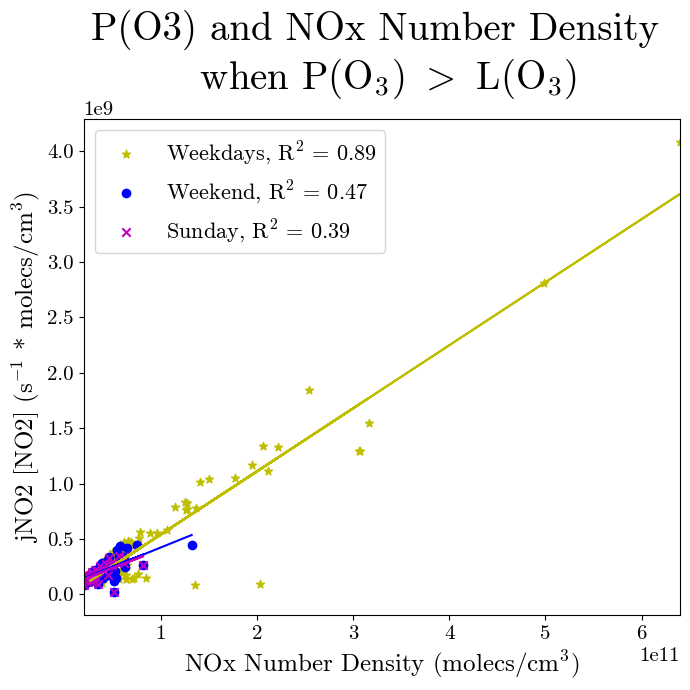

In [30]:
plt.figure(figsize = (7,7), layout='tight')

pearson_coef_weekday = filtered_df_weekday_o3_prod['prod_o3_num'].corr(filtered_df_weekday_o3_prod['num_density_nox'])
slope_weekdays, intercept_weekdays = np.polyfit(filtered_df_weekday_o3_prod['num_density_nox'], filtered_df_weekday_o3_prod['prod_o3_num'], 1)
predicted_weekdays = slope_weekdays * filtered_df_weekday_o3_prod['num_density_nox'] + intercept_weekdays
r_squared_weekdays = r2_score(filtered_df_weekday_o3_prod['prod_o3_num'], predicted_weekdays)
plt.scatter(filtered_df_weekday_o3_prod['num_density_nox'], filtered_df_weekday_o3_prod['prod_o3_num'], color='y', marker = '*')
plt.plot(filtered_df_weekday_o3_prod['num_density_nox'], predicted_weekdays, color = 'y', label='_nolegend_')
print(f'R value: {pearson_coef_weekday}')
print(f'R-squared value: {r_squared_weekdays}')

pearson_coef_weekend = filtered_df_weekend_o3_prod['prod_o3_num'].corr(filtered_df_weekend_o3_prod['num_density_nox'])
slope_weekend, intercept_weekend = np.polyfit(filtered_df_weekend_o3_prod['num_density_nox'], filtered_df_weekend_o3_prod['prod_o3_num'], 1)
predicted_weekend = slope_weekend * filtered_df_weekend_o3_prod['num_density_nox'] + intercept_weekend
r_squared_weekend = r2_score(filtered_df_weekend_o3_prod['prod_o3_num'], predicted_weekend)
plt.scatter(filtered_df_weekend_o3_prod['num_density_nox'], filtered_df_weekend_o3_prod['prod_o3_num'], color='b', marker = 'o')
plt.plot(filtered_df_weekend_o3_prod['num_density_nox'], predicted_weekend, color = 'b', label='_nolegend_')
print(f'R value: {pearson_coef_weekend}')
print(f'R-squared value: {pearson_coef_weekend}')

pearson_coef_sunday = filtered_df_sunday_o3_prod['prod_o3_num'].corr(filtered_df_sunday_o3_prod['num_density_nox'])
slope_sunday, intercept_sunday = np.polyfit(filtered_df_sunday_o3_prod['num_density_nox'], filtered_df_sunday_o3_prod['prod_o3_num'], 1)
predicted_sunday = slope_sunday * filtered_df_sunday_o3_prod['num_density_nox'] + intercept_sunday
r_squared_sunday = r2_score(filtered_df_sunday_o3_prod['prod_o3_num'], predicted_sunday)
plt.scatter(filtered_df_sunday_o3_prod['num_density_nox'], filtered_df_sunday_o3_prod['prod_o3_num'], color='m', marker = 'x')
plt.plot(filtered_df_sunday_o3_prod['num_density_nox'], predicted_sunday, color = 'm', label='_nolegend_')
print(f'R value: {pearson_coef_sunday}')
print(f'R-squared value: {r_squared_sunday}')

plt.ylabel('jNO2 [NO2] (s$^{-1}$ * molecs/cm$^3$)')
plt.xlabel('NOx Number Density (molecs/cm$^3$)')
plt.title('P(O3) and NOx Number Density \n when P(O$_3$) $>$ L(O$_3$)')

labels_with_rsquared = ['Weekdays, R$^2$ = ' + str(round(r_squared_weekdays, 2)), 'Weekend, R$^2$ = ' + str(round(r_squared_weekend, 2)), 'Sunday, R$^2$ = ' + str(round(r_squared_sunday, 2))]
plt.legend(labels_with_rsquared)
plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/prod_o3_nox_scatter_when_leighton_ratio_greatherthan_one_weekdays_weekend_sunday.png', dpi =150)
plt.show()

/tmp/ipykernel_3838838/516145558.py:7: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.scatter(filtered_df_weekday_o3_prod['num_density_nox'], filtered_df_weekday_o3_prod['prod_o3_num'], color='y', marker = '*')


R value: 0.943509127214151
R-squared value: 0.8902094731364089


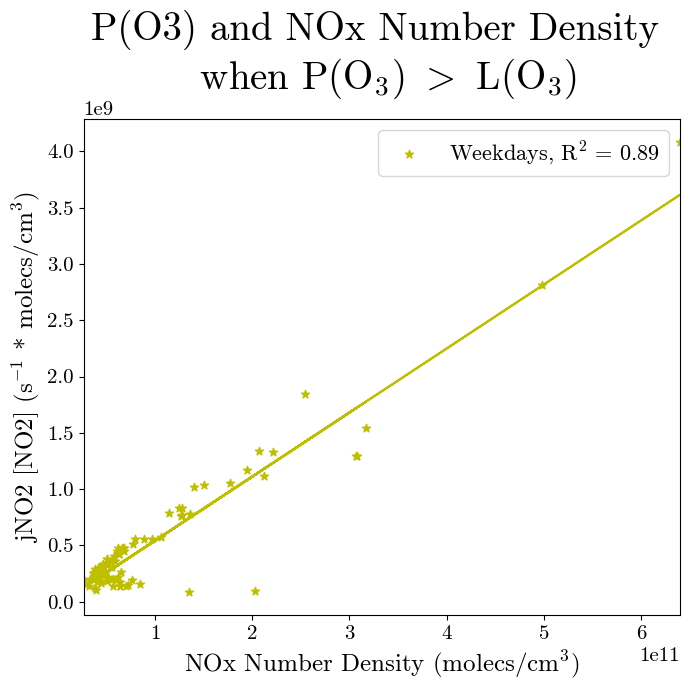

In [31]:
plt.figure(figsize = (7,7), layout='tight')

pearson_coef_weekday = filtered_df_weekday_o3_prod['prod_o3_num'].corr(filtered_df_weekday_o3_prod['num_density_nox'])
slope_weekdays, intercept_weekdays = np.polyfit(filtered_df_weekday_o3_prod['num_density_nox'], filtered_df_weekday_o3_prod['prod_o3_num'], 1)
predicted_weekdays = slope_weekdays * filtered_df_weekday_o3_prod['num_density_nox'] + intercept_weekdays
r_squared_weekdays = r2_score(filtered_df_weekday_o3_prod['prod_o3_num'], predicted_weekdays)
plt.scatter(filtered_df_weekday_o3_prod['num_density_nox'], filtered_df_weekday_o3_prod['prod_o3_num'], color='y', marker = '*')
plt.plot(filtered_df_weekday_o3_prod['num_density_nox'], predicted_weekdays, color = 'y', label='_nolegend_')
print(f'R value: {pearson_coef_weekday}')
print(f'R-squared value: {r_squared_weekdays}')

plt.ylabel('jNO2 [NO2] (s$^{-1}$ * molecs/cm$^3$)')
plt.xlabel('NOx Number Density (molecs/cm$^3$)')
plt.title('P(O3) and NOx Number Density \n when P(O$_3$) $>$ L(O$_3$)')

labels_with_rsquared = ['Weekdays, R$^2$ = ' + str(round(r_squared_weekdays, 2))]
plt.legend(labels_with_rsquared)
plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/prod_o3_nox_scatter_when_leighton_ratio_greatherthan_one_weekdays_only.png', dpi =150)
plt.show()

/tmp/ipykernel_3838838/415394101.py:7: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.scatter(filtered_df_weekend_o3_prod['num_density_nox'], filtered_df_weekend_o3_prod['prod_o3_num'], color='b', marker = 'o')


R value: 0.6889096900048292
R-squared value: 0.47459656098254954
R value: 0.623051255503211
R-squared value: 0.3881928669841278


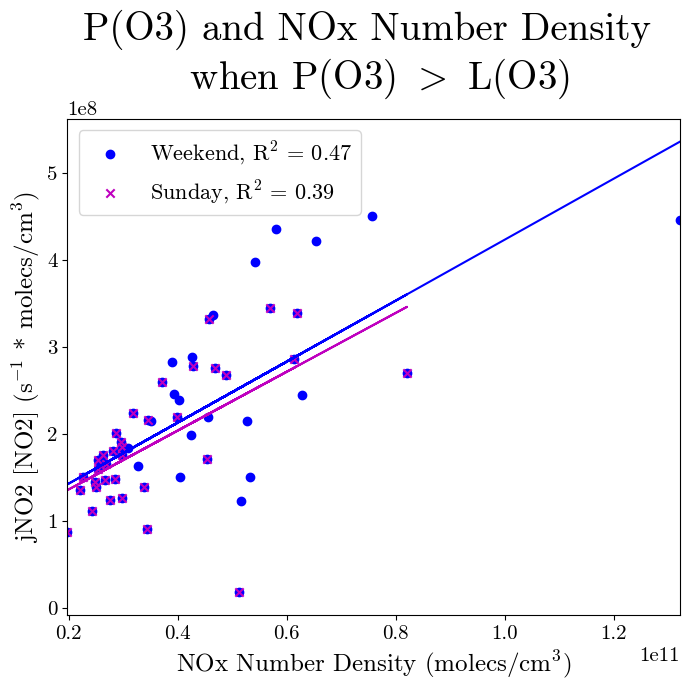

In [32]:
plt.figure(figsize = (7,7), layout='tight')

pearson_coef_weekend = filtered_df_weekend_o3_prod['prod_o3_num'].corr(filtered_df_weekend_o3_prod['num_density_nox'])
slope_weekend, intercept_weekend = np.polyfit(filtered_df_weekend_o3_prod['num_density_nox'], filtered_df_weekend_o3_prod['prod_o3_num'], 1)
predicted_weekend = slope_weekend * filtered_df_weekend_o3_prod['num_density_nox'] + intercept_weekend
r_squared_weekend = r2_score(filtered_df_weekend_o3_prod['prod_o3_num'], predicted_weekend)
plt.scatter(filtered_df_weekend_o3_prod['num_density_nox'], filtered_df_weekend_o3_prod['prod_o3_num'], color='b', marker = 'o')
plt.plot(filtered_df_weekend_o3_prod['num_density_nox'], predicted_weekend, color = 'b', label='_nolegend_')
print(f'R value: {pearson_coef_weekend}')
print(f'R-squared value: {r_squared_weekend}')

pearson_coef_sunday = filtered_df_sunday_o3_prod['prod_o3_num'].corr(filtered_df_sunday_o3_prod['num_density_nox'])
slope_sunday, intercept_sunday = np.polyfit(filtered_df_sunday_o3_prod['num_density_nox'], filtered_df_sunday_o3_prod['prod_o3_num'], 1)
predicted_sunday = slope_sunday * filtered_df_sunday_o3_prod['num_density_nox'] + intercept_sunday
r_squared_sunday = r2_score(filtered_df_sunday_o3_prod['prod_o3_num'], predicted_sunday)
plt.scatter(filtered_df_sunday_o3_prod['num_density_nox'], filtered_df_sunday_o3_prod['prod_o3_num'], color='m', marker = 'x')
plt.plot(filtered_df_sunday_o3_prod['num_density_nox'], predicted_sunday, color = 'm', label='_nolegend_')
print(f'R value: {pearson_coef_sunday}')
print(f'R-squared value: {r_squared_sunday}')

plt.ylabel('jNO2 [NO2] (s$^{-1}$ * molecs/cm$^3$)')
plt.xlabel('NOx Number Density (molecs/cm$^3$)')
plt.title('P(O3) and NOx Number Density \n when P(O3) $>$ L(O3)')

labels_with_rsquared = ['Weekend, R$^2$ = ' + str(round(r_squared_weekend, 2)), 'Sunday, R$^2$ = ' + str(round(r_squared_sunday, 2))]
plt.legend(labels_with_rsquared)
plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/prod_o3_nox_scatter_when_leighton_ratio_greatherthan_one_weekend_sunday_only.png', dpi =150)
plt.show()

/tmp/ipykernel_3838838/2400436016.py:2: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.scatter(filtered_df_weekday_o3_prod['num_density_nox'], filtered_df_weekday_o3_prod['num_density_o3'], color='y', marker = '*', label = 'Weekday')


Text(0.5, 1.0, 'O3 and NOx Number Density \nwhen the Leighton Ratio > 1')

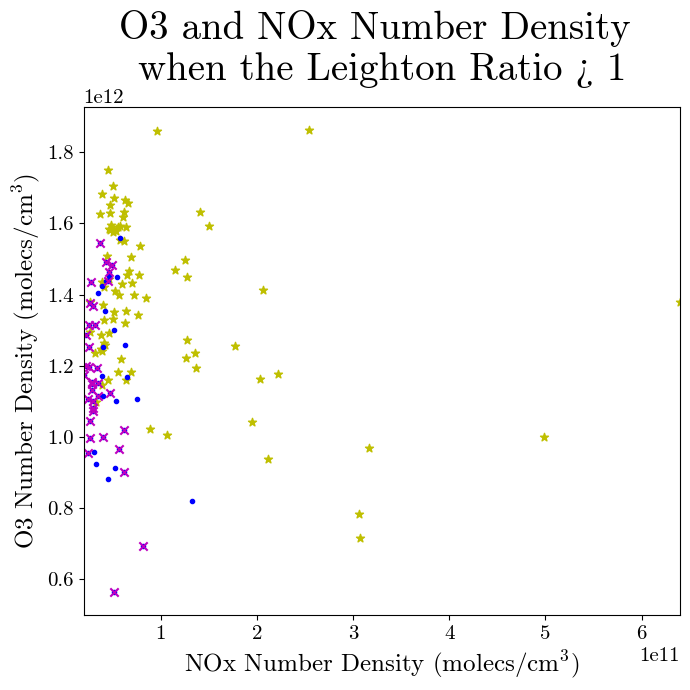

In [33]:
plt.figure(figsize = (7,7), layout='tight')
plt.scatter(filtered_df_weekday_o3_prod['num_density_nox'], filtered_df_weekday_o3_prod['num_density_o3'], color='y', marker = '*', label = 'Weekday')
plt.scatter(filtered_df_weekend_o3_prod['num_density_nox'], filtered_df_weekend_o3_prod['num_density_o3'], color='b', marker = '.', label = 'Weekend')
plt.scatter(filtered_df_sunday_o3_prod['num_density_nox'], filtered_df_sunday_o3_prod['num_density_o3'], color='m', marker = 'x', label = 'Sunday')
plt.ylabel('O3 Number Density (molecs/cm$^3$)')
plt.xlabel('NOx Number Density (molecs/cm$^3$)')
plt.title('O3 and NOx Number Density \nwhen the Leighton Ratio > 1')

/tmp/ipykernel_3838838/1167352259.py:6: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.scatter(filtered_df_weekend_o3_prod['num_density_nox'], filtered_df_weekend_o3_prod['num_density_o3'], color='b', marker = 'o')


R value: -0.2664268861825912
R-squared value: 0.07098328568095136
R value: -0.3690687427785686
R-squared value: 0.13621173689615318


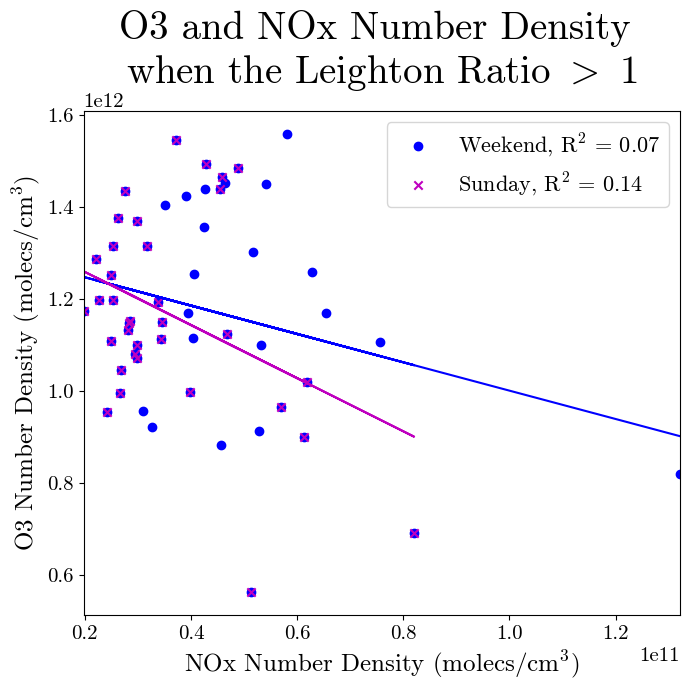

In [34]:
plt.figure(figsize = (7,7), layout='tight')
pearson_coef_weekend = filtered_df_weekend_o3_prod['num_density_o3'].corr(filtered_df_weekend_o3_prod['num_density_nox'])
slope_weekend, intercept_weekend = np.polyfit(filtered_df_weekend_o3_prod['num_density_nox'], filtered_df_weekend_o3_prod['num_density_o3'], 1)
predicted_weekend = slope_weekend * filtered_df_weekend_o3_prod['num_density_nox'] + intercept_weekend
r_squared_weekend = r2_score(filtered_df_weekend_o3_prod['num_density_o3'], predicted_weekend)
plt.scatter(filtered_df_weekend_o3_prod['num_density_nox'], filtered_df_weekend_o3_prod['num_density_o3'], color='b', marker = 'o')
plt.plot(filtered_df_weekend_o3_prod['num_density_nox'], predicted_weekend, color = 'b', label='_nolegend_')
print(f'R value: {pearson_coef_weekend}')
print(f'R-squared value: {r_squared_weekend}')

pearson_coef_sunday = filtered_df_sunday_o3_prod['num_density_o3'].corr(filtered_df_sunday_o3_prod['num_density_nox'])
slope_sunday, intercept_sunday = np.polyfit(filtered_df_sunday_o3_prod['num_density_nox'], filtered_df_sunday_o3_prod['num_density_o3'], 1)
predicted_sunday = slope_sunday * filtered_df_sunday_o3_prod['num_density_nox'] + intercept_sunday
r_squared_sunday = r2_score(filtered_df_sunday_o3_prod['num_density_o3'], predicted_sunday)
plt.scatter(filtered_df_sunday_o3_prod['num_density_nox'], filtered_df_sunday_o3_prod['num_density_o3'], color='m', marker = 'x')
plt.plot(filtered_df_sunday_o3_prod['num_density_nox'], predicted_sunday, color = 'm', label='_nolegend_')
print(f'R value: {pearson_coef_sunday}')
print(f'R-squared value: {r_squared_sunday}')

labels_with_rsquared = ['Weekend, R$^2$ = ' + str(round(r_squared_weekend, 2)), 'Sunday, R$^2$ = ' + str(round(r_squared_sunday, 2))]

#plt.scatter(filtered_df_weekday_o3_prod['num_density_nox'], filtered_df_weekday_o3_prod['num_density_o3'], color='y', marker = '*', label = 'Weekday')
# plt.scatter(filtered_df_weekend_o3_prod['num_density_nox'], filtered_df_weekend_o3_prod['num_density_o3'], color='b', marker = '.', label = 'Weekend')
# plt.scatter(filtered_df_sunday_o3_prod['num_density_nox'], filtered_df_sunday_o3_prod['num_density_o3'], color='m', marker = 'x', label = 'Sunday')
plt.ylabel('O3 Number Density (molecs/cm$^3$)')
plt.xlabel('NOx Number Density (molecs/cm$^3$)')
plt.title('O3 and NOx Number Density \nwhen the Leighton Ratio $>$ 1')
plt.legend(labels_with_rsquared)
plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/o3_nox_scatter_when_leighton_ratio_greatherthan_one_weekend_sunday_only.png', dpi =150)
plt.show()

/tmp/ipykernel_3838838/3990436965.py:6: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.scatter(filtered_df_weekday_o3_prod['num_density_nox'], filtered_df_weekday_o3_prod['num_density_o3'], color='y', marker = '*')


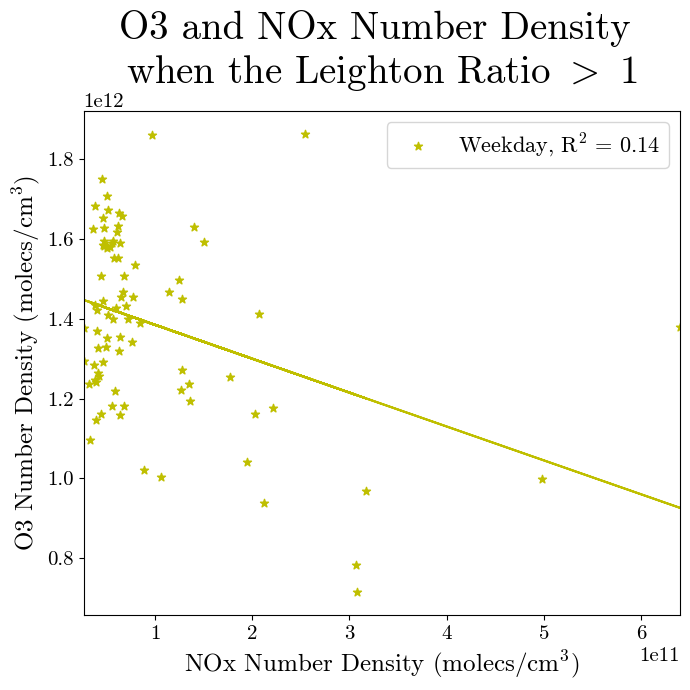

In [35]:
plt.figure(figsize = (7,7), layout='tight')
pearson_coef_weekday = filtered_df_weekday_o3_prod['num_density_o3'].corr(filtered_df_weekday_o3_prod['num_density_nox'])
slope_weekday, intercept_weekday = np.polyfit(filtered_df_weekday_o3_prod['num_density_nox'], filtered_df_weekday_o3_prod['num_density_o3'], 1)
predicted_weekday = slope_weekday * filtered_df_weekday_o3_prod['num_density_nox'] + intercept_weekday
r_squared_weekday = r2_score(filtered_df_weekday_o3_prod['num_density_o3'], predicted_weekday)
plt.scatter(filtered_df_weekday_o3_prod['num_density_nox'], filtered_df_weekday_o3_prod['num_density_o3'], color='y', marker = '*')
plt.plot(filtered_df_weekday_o3_prod['num_density_nox'], predicted_weekday, color = 'y', label='_nolegend_')

labels_with_rsquared = ['Weekday, R$^2$ = ' + str(round(r_squared_weekday, 2))]
plt.legend(labels_with_rsquared, loc = 'upper right')

#plt.figure(figsize = (7,7), layout='tight')
plt.ylabel('O3 Number Density (molecs/cm$^3$)')
plt.xlabel('NOx Number Density (molecs/cm$^3$)')
plt.title('O3 and NOx Number Density \nwhen the Leighton Ratio $>$ 1')
plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/o3_nox_scatter_when_leighton_ratio_greatherthan_one_weekdays_only.png', dpi =150)
plt.show()

In [36]:
filtered_df_weekday = df_alldays[(df_alldays['Weekday'] == 'Weekday')]
filtered_df_weekend = df_alldays[(df_alldays['Weekday'] == 'Weekend')]
filtered_df_sunday = df_alldays[(df_alldays['Sunday'] == 'Sunday')]


/tmp/ipykernel_3838838/3282593575.py:2: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.scatter(filtered_df_weekday['NOx_ppbv'], filtered_df_weekday['O3_ppbv'], color='y', marker = '*')


Text(0.5, 1.0, 'O3 and NOx Mixing Ratio \nfor whole campaign')

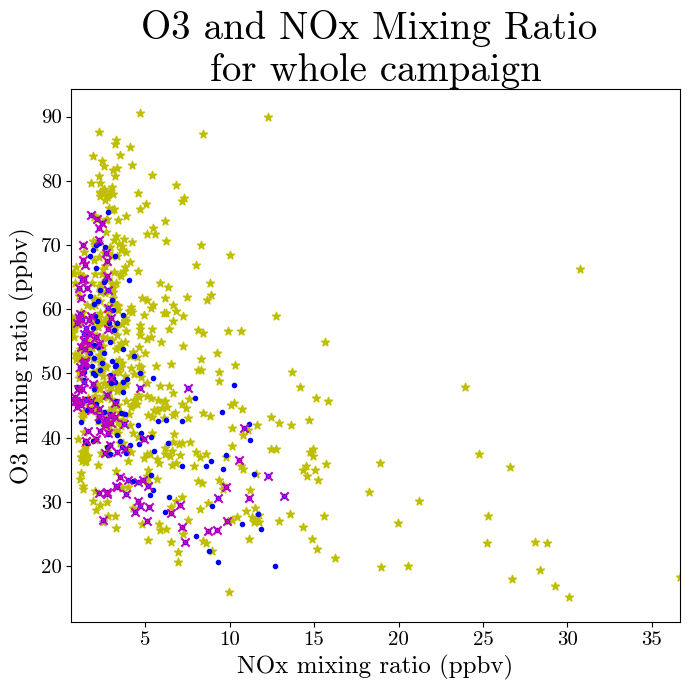

In [37]:
plt.figure(figsize = (7,7), layout='tight')
plt.scatter(filtered_df_weekday['NOx_ppbv'], filtered_df_weekday['O3_ppbv'], color='y', marker = '*')
plt.scatter(filtered_df_weekend['NOx_ppbv'], filtered_df_weekend['O3_ppbv'], color='b', marker = '.')
plt.scatter(filtered_df_sunday['NOx_ppbv'], filtered_df_sunday['O3_ppbv'], color='m', marker = 'x')
plt.ylabel('O3 mixing ratio (ppbv)')
plt.xlabel('NOx mixing ratio (ppbv)')
plt.title('O3 and NOx Mixing Ratio \nfor whole campaign')


/tmp/ipykernel_3838838/4239358124.py:2: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.scatter(filtered_df_weekday['num_density_nox'], filtered_df_weekday['num_density_o3'], color='y', marker = '*', label = 'Weekday')


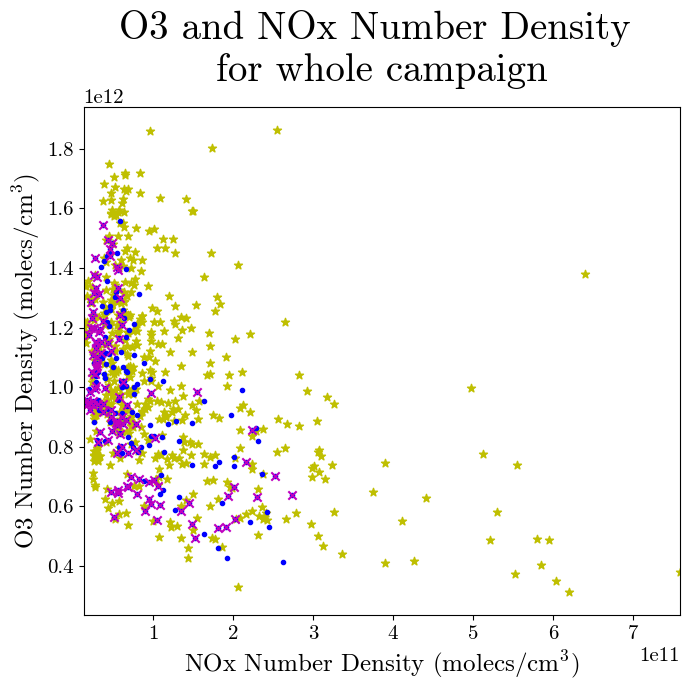

In [38]:
plt.figure(figsize = (7,7), layout='tight')
plt.scatter(filtered_df_weekday['num_density_nox'], filtered_df_weekday['num_density_o3'], color='y', marker = '*', label = 'Weekday')
plt.scatter(filtered_df_weekend['num_density_nox'], filtered_df_weekend['num_density_o3'], color='b', marker = '.', label = 'Weekend')
plt.scatter(filtered_df_sunday['num_density_nox'], filtered_df_sunday['num_density_o3'], color='m', marker = 'x', label = 'sunday')

plt.ylabel('O3 Number Density (molecs/cm$^3$)')
plt.xlabel('NOx Number Density (molecs/cm$^3$)')
plt.title('O3 and NOx Number Density \nfor whole campaign')
plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/o3_nox_scatter_whole_campaign.png', dpi =150)
plt.show()

/tmp/ipykernel_3838838/3642780495.py:2: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.scatter(filtered_df_weekday['num_density_o3'], filtered_df_weekday['prod_o3_num'], color='y', marker = '*', label = 'Weekday')


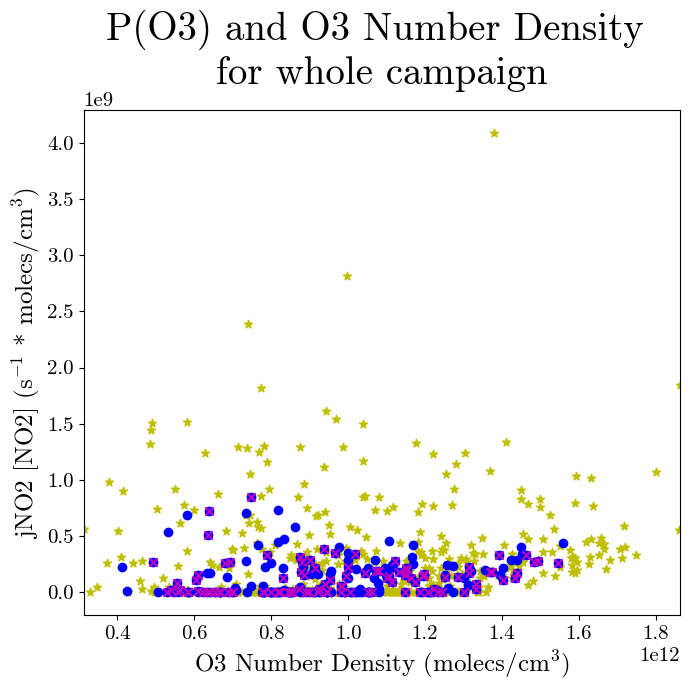

In [39]:
plt.figure(figsize = (7,7), layout='tight')
plt.scatter(filtered_df_weekday['num_density_o3'], filtered_df_weekday['prod_o3_num'], color='y', marker = '*', label = 'Weekday')
plt.scatter(filtered_df_weekend['num_density_o3'], filtered_df_weekend['prod_o3_num'], color='b', marker = 'o', label = 'Weekend')
plt.scatter(filtered_df_sunday['num_density_o3'], filtered_df_sunday['prod_o3_num'], color='m', marker = 'x', label = 'Sunday')
plt.ylabel('jNO2 [NO2] (s$^{-1}$ * molecs/cm$^3$)')
plt.xlabel('O3 Number Density (molecs/cm$^3$)')
plt.title('P(O3) and O3 Number Density \nfor whole campaign')
plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/jno2-no2_nox_scatter_whole_campaign.png', dpi =150)
plt.show()

/tmp/ipykernel_3838838/817853185.py:2: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.scatter(filtered_df_weekday['num_density_nox'], filtered_df_weekday['prod_o3_num'], color='y', marker = '*', label = 'Weekday')


Text(0.5, 1.0, 'P(O3) and NOx Number Density \nfor whole campaign')

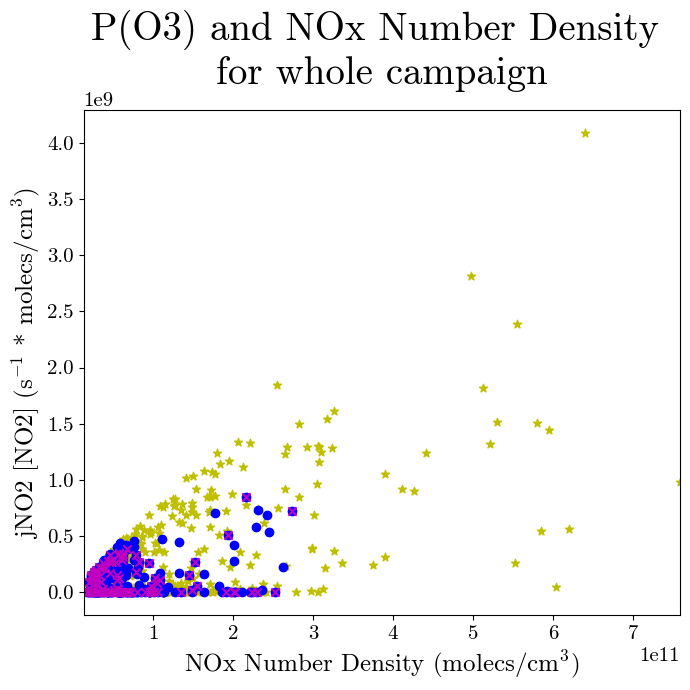

In [40]:
plt.figure(figsize = (7,7), layout='tight')
plt.scatter(filtered_df_weekday['num_density_nox'], filtered_df_weekday['prod_o3_num'], color='y', marker = '*', label = 'Weekday')
plt.scatter(filtered_df_weekend['num_density_nox'], filtered_df_weekend['prod_o3_num'], color='b', marker = 'o', label = 'Weekend')
plt.scatter(filtered_df_sunday['num_density_nox'], filtered_df_sunday['prod_o3_num'], color='m', marker = 'x', label = 'Sunday')
plt.ylabel('jNO2 [NO2] (s$^{-1}$ * molecs/cm$^3$)')
plt.xlabel('NOx Number Density (molecs/cm$^3$)')
plt.title('P(O3) and NOx Number Density \nfor whole campaign')

In [41]:
filtered_df_weekday_o3_loss = df_alldays[(df_alldays['leighton ratio'] < 1) & (df_alldays['Weekday'] == 'Weekday')]
filtered_df_weekend_o3_loss = df_alldays[(df_alldays['leighton ratio'] < 1) & (df_alldays['Weekday'] == 'Weekend')]
filtered_df_sunday_o3_loss = df_alldays[(df_alldays['leighton ratio'] < 1) & (df_alldays['Sunday'] == 'Sunday')]

/tmp/ipykernel_3838838/3383000226.py:2: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.scatter(filtered_df_weekday_o3_loss['num_density_nox'], filtered_df_weekday_o3_loss['prod_o3_num'], color='y', marker = '*', label = 'Weekday')


Text(0.5, 1.0, 'P(O3) and NOx Number Density \n when P(O3) $<$ L(O3)')

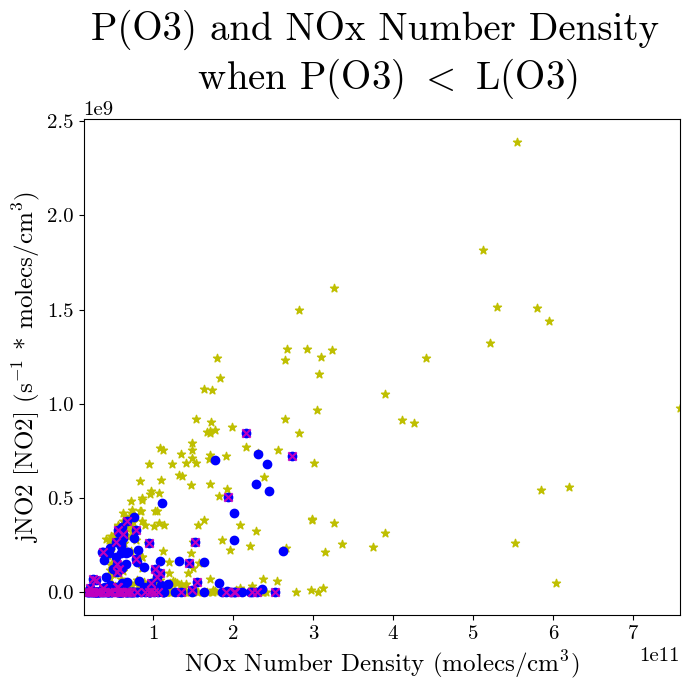

In [42]:
plt.figure(figsize = (7,7), layout='tight')
plt.scatter(filtered_df_weekday_o3_loss['num_density_nox'], filtered_df_weekday_o3_loss['prod_o3_num'], color='y', marker = '*', label = 'Weekday')
plt.scatter(filtered_df_weekend_o3_loss['num_density_nox'], filtered_df_weekend_o3_loss['prod_o3_num'], color='b', marker = 'o', label = 'Weekend')
plt.scatter(filtered_df_sunday_o3_loss['num_density_nox'], filtered_df_sunday_o3_loss['prod_o3_num'], color='m', marker = 'x', label = 'Sunday')
plt.ylabel('jNO2 [NO2] (s$^{-1}$ * molecs/cm$^3$)')
plt.xlabel('NOx Number Density (molecs/cm$^3$)')
plt.title('P(O3) and NOx Number Density \n when P(O3) $<$ L(O3)')

/tmp/ipykernel_3838838/2935183083.py:2: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.scatter(filtered_df_weekday_o3_loss['num_density_nox'], filtered_df_weekday_o3_loss['loss_o3_den'], color='y', marker = '*', label = 'Weekday')


Text(0.5, 1.0, 'L(O3) and NOx Number Density \n when P(O3) $<$ L(O3)')

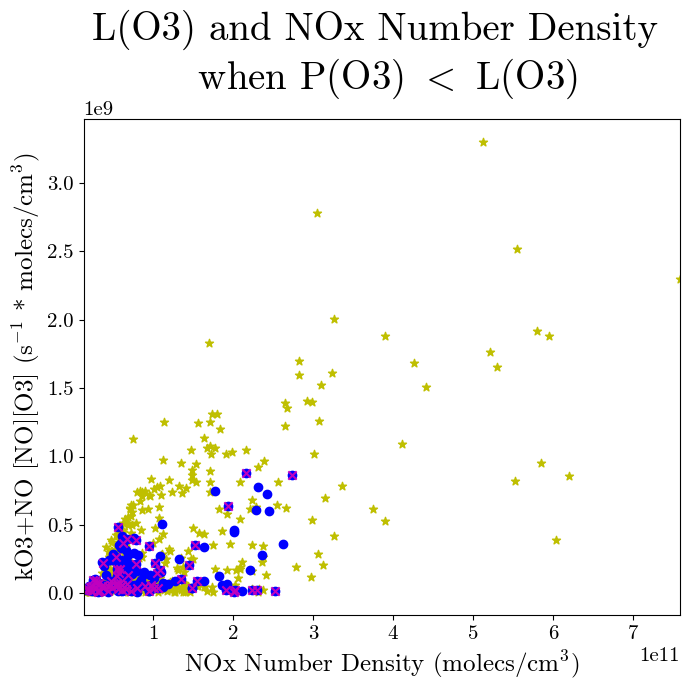

In [43]:
plt.figure(figsize = (7,7), layout='tight')
plt.scatter(filtered_df_weekday_o3_loss['num_density_nox'], filtered_df_weekday_o3_loss['loss_o3_den'], color='y', marker = '*', label = 'Weekday')
plt.scatter(filtered_df_weekend_o3_loss['num_density_nox'], filtered_df_weekend_o3_loss['loss_o3_den'], color='b', marker = 'o', label = 'Weekend')
plt.scatter(filtered_df_sunday_o3_loss['num_density_nox'], filtered_df_sunday_o3_loss['loss_o3_den'], color='m', marker = 'x', label = 'Sunday')
plt.ylabel('kO3+NO [NO][O3] (s$^{-1}$ * molecs/cm$^3$)')
plt.xlabel('NOx Number Density (molecs/cm$^3$)')
plt.title('L(O3) and NOx Number Density \n when P(O3) $<$ L(O3)')